In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Set up visual style and ensure the data directory exists
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
os.makedirs('./data', exist_ok=True)

print("Libraries loaded and directory ready.")

Libraries loaded and directory ready.


In [2]:
print("Downloading Measuring Hate Speech dataset from HuggingFace...")

# Load the dataset (MHS only has a 'train' split by default)
dataset = load_dataset("ucberkeley-dlab/measuring-hate-speech", 'default')
df = dataset['train'].to_pandas()

print(f"Download complete. Total rows: {len(df):,}")

# Save the full dataset locally so you can inspect it manually
csv_path = './data/mhs_full_dataset.csv'
df.to_csv(csv_path, index=False)
print(f"Dataset fully saved to: {csv_path}")

# Display the first few rows to verify the columns
display(df.head(3))

Download complete. Total rows: 135,556
Dataset fully saved to: ./data/mhs_full_dataset.csv


,comment_id,annotator_id,platform,sentiment,respect,insult,humiliate,status,dehumanize,violence,...,annotator_religion_hindu,annotator_religion_jewish,annotator_religion_mormon,annotator_religion_muslim,annotator_religion_nothing,annotator_religion_other,annotator_sexuality_bisexual,annotator_sexuality_gay,annotator_sexuality_straight,annotator_sexuality_other
0,47777,10873,3,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
1,39773,2790,2,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
2,47101,3379,3,4.0,4.0,4.0,4.0,4.0,4.0,0.0,...,False,False,False,False,True,False,False,False,True,False


In [3]:
# The actual text being evaluated is in the 'text' column
unique_sentences = df['text'].nunique()

# The human annotators are tracked in the 'annotator_id' column
unique_annotators = df['annotator_id'].nunique()

print("--- MHS Dataset Integrity Check ---")
print(f"Total Unique Sentences: {unique_sentences:,}")
print(f"Total Unique Human Annotators: {unique_annotators:,}")

--- MHS Dataset Integrity Check ---
Total Unique Sentences: 39,565
Total Unique Human Annotators: 7,912


In [4]:
# 1. Group by text and count unique annotators
top_sentences = df.groupby('text')['annotator_id'].nunique().reset_index()

# 2. Rename columns for clarity
top_sentences.columns = ['Sentence', 'Unique_Annotators']

# 3. Sort by the highest number of annotators and grab the top 25
top_25 = top_sentences.sort_values(by='Unique_Annotators', ascending=False).head(50)

# 4. Truncate the text to 100 characters so it doesn't break your notebook's formatting
top_25['Sentence'] = top_25['Sentence'].apply(lambda x: (x[:100] + '...') if len(x) > 100 else x)

# 5. Make the index start at 1 instead of 0 for a proper ranked list
top_25 = top_25.reset_index(drop=True)
top_25.index = top_25.index + 1

print("--- Top 25 Most Heavily Annotated Sentences in MHS ---")
display(top_25)

--- Top 25 Most Heavily Annotated Sentences in MHS ---


,Sentence,Unique_Annotators
1,JEW Get the fuck out of here you jewish son of...,815
2,"yeah, heres a clue for the nigger author of th...",801
3,@Legionary1488 @JomavaesJos now we have a Eblo...,799
4,Every slant in #LosAngeles should be deported....,796
5,Why do so many filthy wetback half-breed spic ...,793
6,@Cam_Coles You don't know what I know. Name so...,793
7,gay people should die,791
8,i hate jews so much i wish the holocaust actua...,790
9,trump is the only jews true friend. I hope tru...,786
10,GET RID OF THOSE FUCKING MUSLIMS! the nasty on...,784


In [5]:
# 1. Check original shape
print(f"Original columns: {df.shape[1]}")

# 2. Identify all columns that start with "target"
columns_to_drop = [col for col in df.columns if col.startswith('target')]

# 3. Drop them to create the polished dataset
polished_df = df.drop(columns=columns_to_drop)

# 4. Verify the new shape and columns
print(f"Polished columns: {polished_df.shape[1]}")
print(f"Dropped {len(columns_to_drop)} 'target_' columns.")

# Optional: Display the remaining columns just to verify you have what you need
print("\nRemaining Columns:")
print(list(polished_df.columns))

Original columns: 143
Polished columns: 78
Dropped 65 'target_' columns.

Remaining Columns:
['comment_id', 'annotator_id', 'platform', 'sentiment', 'respect', 'insult', 'humiliate', 'status', 'dehumanize', 'violence', 'genocide', 'attack_defend', 'hatespeech', 'hate_speech_score', 'text', 'infitms', 'outfitms', 'annotator_severity', 'std_err', 'annotator_infitms', 'annotator_outfitms', 'hypothesis', 'annotator_gender', 'annotator_trans', 'annotator_educ', 'annotator_income', 'annotator_ideology', 'annotator_gender_men', 'annotator_gender_women', 'annotator_gender_non_binary', 'annotator_gender_prefer_not_to_say', 'annotator_gender_self_describe', 'annotator_transgender', 'annotator_cisgender', 'annotator_transgender_prefer_not_to_say', 'annotator_education_some_high_school', 'annotator_education_high_school_grad', 'annotator_education_some_college', 'annotator_education_college_grad_aa', 'annotator_education_college_grad_ba', 'annotator_education_professional_degree', 'annotator_educa

In [6]:
print("--- Round 2: Mining with Raw Annotator Votes ---")

# 1. Use the RAW annotator column ('hatespeech') instead of the aggregated score.
# A value > 0 means they considered it at least somewhat hate speech.
polished_df['is_hate_speech_binary'] = (polished_df['hatespeech'] > 0).astype(int)

# 2. Recalculate the sentence stats
sentence_stats = polished_df.groupby('text').agg(
    total_annotators=('annotator_id', 'nunique'),
    hate_speech_ratio=('is_hate_speech_binary', 'mean')
).reset_index()

# 3. Filter for robust sentences (>= 50 unique annotators)
heavy_hitters = sentence_stats[sentence_stats['total_annotators'] >= 20].copy()

# 4. Filter for the 40% to 60% perfectly divided Goldilocks zone
balanced_sentences = heavy_hitters[
    (heavy_hitters['hate_speech_ratio'] >= 0.30) & 
    (heavy_hitters['hate_speech_ratio'] <= 0.70)
].copy()

# 5. Sort by the most total annotators
balanced_sentences = balanced_sentences.sort_values(by='total_annotators', ascending=False)
balanced_sentences['hate_speech_ratio'] = (balanced_sentences['hate_speech_ratio'] * 100).round(1).astype(str) + '%'

print(f"✅ Found {len(balanced_sentences)} perfectly divided (controversial) sentences!")
print("--- Top 10 Most Annotated, Perfectly Balanced Sentences ---")
with pd.option_context('display.max_colwidth', None):
    display(balanced_sentences.head(20))

# Overwrite our previous file with the CORRECT controversial sentences
balanced_sentences.to_csv('./data/mhs_perfectly_balanced_for_llm.csv', index=False)

--- Round 2: Mining with Raw Annotator Votes ---
✅ Found 11 perfectly divided (controversial) sentences!
--- Top 10 Most Annotated, Perfectly Balanced Sentences ---


,text,total_annotators,hate_speech_ratio
36546,gay people should die,791,62.5%
36926,i hate jews so much i wish the holocaust actually happened,790,69.0%
22359,"My God look at these BARBARIC PPL. And these pigs all watching. They r a very, very sick culture. And Omar and Rashid want this crap here. This is America not the Middle East. Round them up and send them home.",778,66.1%
24961,"RT @JihadistJoe: We Muslims have no military honour whatsoever, we are sub human savages that slaughter unarmed men, women & children http:…",772,56.7%
29612,"They all need to be Kicked, taken out of our country. Obama brought them all in Illegally. Send the Trash back to there own country",768,61.6%
20754,"Lady in the back Blinks when ""her"" camera red light goes on. Part of the tranny SHOW. Before ya deny...see: Transvestigations on Yt. Trannies are PROUD to show How It's Done!👍",695,48.6%
33150,Who hurt you? Lol. It's comical how stupid and angry you people are. MEH AMURICA. MY LAND. MINE. BANG BANG GUNS. NO BROWN PEOPLE. WAHH.,558,34.4%
37224,"im ,i hate black people and minorities",392,35.2%
20820,Learn the fucking language you fucking useless immigrant.,391,68.3%
7126,"Aint nobody wearing those new Westbrook ""Jordan's"" but Mexicans & trailer park trash white girls.",389,62.2%


In [7]:
print("--- 3-Class Distribution of our Controversial Sentences ---")

# 1. Get the raw votes for the controversial sentences we just found
balanced_texts = balanced_sentences['text'].tolist()
raw_votes = polished_df[polished_df['text'].isin(balanced_texts)]

# 2. Calculate what percentage of humans voted 0, 1, or 2 for each text
dist_df = raw_votes.groupby('text')['hatespeech'].value_counts(normalize=True).unstack(fill_value=0)

# 3. Rename columns and format as percentages
dist_df.columns = ['% Voted 0 (Not Hate)', '% Voted 1 (Hate)', '% Voted 2 (Extreme)']
dist_df = (dist_df * 100).round(1).astype(str) + '%'

# 4. Merge back with our total annotator counts
final_view = balanced_sentences[['text', 'total_annotators']].merge(dist_df, on='text', how='left')

with pd.option_context('display.max_colwidth', None):
    display(final_view.head(10))

--- 3-Class Distribution of our Controversial Sentences ---


,text,total_annotators,% Voted 0 (Not Hate),% Voted 1 (Hate),% Voted 2 (Extreme)
0,gay people should die,791,37.5%,5.4%,57.0%
1,i hate jews so much i wish the holocaust actually happened,790,31.0%,8.7%,60.3%
2,"My God look at these BARBARIC PPL. And these pigs all watching. They r a very, very sick culture. And Omar and Rashid want this crap here. This is America not the Middle East. Round them up and send them home.",778,33.9%,10.9%,55.1%
3,"RT @JihadistJoe: We Muslims have no military honour whatsoever, we are sub human savages that slaughter unarmed men, women & children http:…",772,43.3%,9.3%,47.4%
4,"They all need to be Kicked, taken out of our country. Obama brought them all in Illegally. Send the Trash back to there own country",768,38.4%,9.1%,52.5%
5,"Lady in the back Blinks when ""her"" camera red light goes on. Part of the tranny SHOW. Before ya deny...see: Transvestigations on Yt. Trannies are PROUD to show How It's Done!👍",695,51.4%,16.3%,32.4%
6,Who hurt you? Lol. It's comical how stupid and angry you people are. MEH AMURICA. MY LAND. MINE. BANG BANG GUNS. NO BROWN PEOPLE. WAHH.,558,65.6%,8.4%,26.0%
7,"im ,i hate black people and minorities",392,64.8%,5.6%,29.6%
8,Learn the fucking language you fucking useless immigrant.,391,31.7%,7.4%,60.9%
9,"Aint nobody wearing those new Westbrook ""Jordan's"" but Mexicans & trailer park trash white girls.",389,37.8%,9.5%,52.7%


--- Unique Annotator Demographics ---
Total Unique Annotators: 7,912



/tmp/ipykernel_7706/2051671065.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_7706/2051671065.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_7706/2051671065.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_7706/2051671065.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


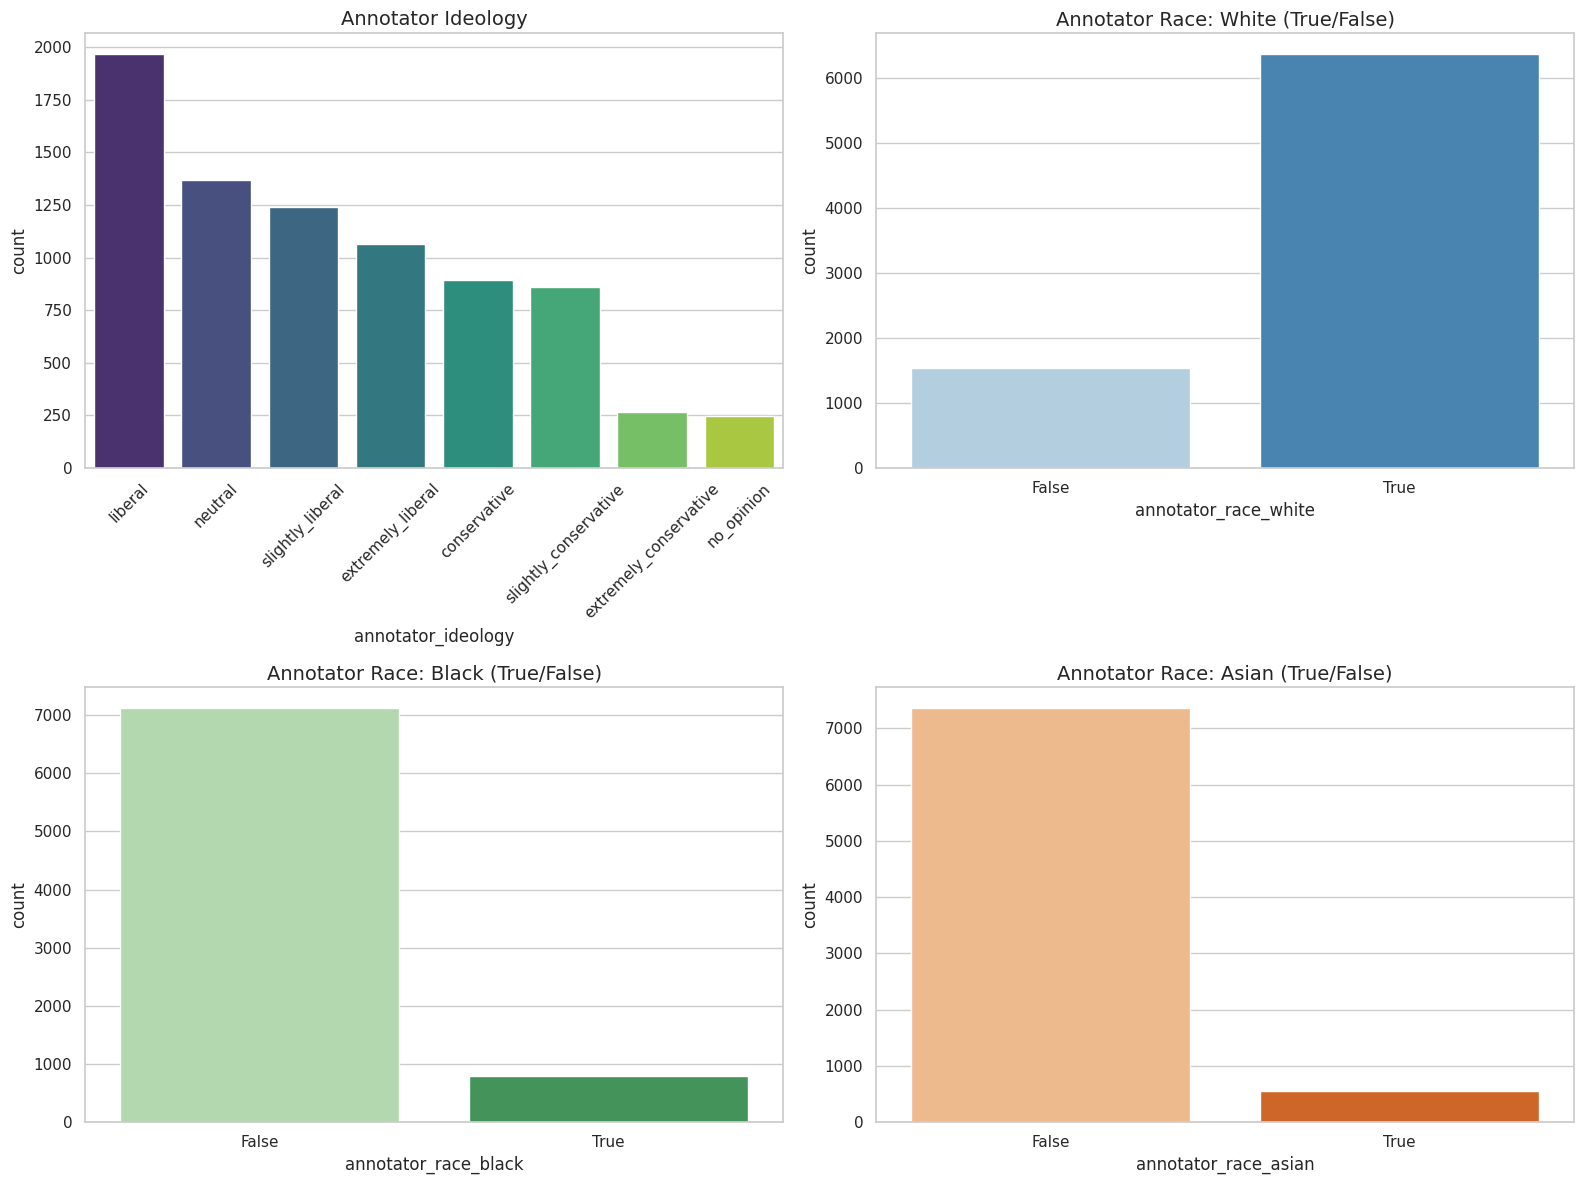

--- Raw Counts ---
annotator_ideology
liberal                   1968
neutral                   1367
slightly_liberal          1242
extremely_liberal         1065
conservative               895
slightly_conservative      860
extremely_conservative     264
no_opinion                 249
Name: count, dtype: int64 

White: {True: 6373, False: 1539}
Black: {False: 7121, True: 791}
Asian: {False: 7360, True: 552}


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Unique Annotator Demographics ---")

# 1. Isolate unique annotators so we don't overcount people who did 1,000 sentences
# (Assuming your dataframe is named 'polished_df' or 'df')
unique_annotators = polished_df.drop_duplicates(subset=['annotator_id']).copy()

print(f"Total Unique Annotators: {len(unique_annotators):,}\n")

# 2. Set up a 2x2 grid for our 4 plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# Plot 1: Ideology
sns.countplot(
    data=unique_annotators, 
    x='annotator_ideology', 
    ax=axes[0, 0], 
    order=unique_annotators['annotator_ideology'].value_counts().index, 
    palette='viridis'
)
axes[0, 0].set_title('Annotator Ideology', fontsize=14)
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Race - White
sns.countplot(
    data=unique_annotators, 
    x='annotator_race_white', 
    ax=axes[0, 1], 
    palette='Blues'
)
axes[0, 1].set_title('Annotator Race: White (True/False)', fontsize=14)

# Plot 3: Race - Black
sns.countplot(
    data=unique_annotators, 
    x='annotator_race_black', 
    ax=axes[1, 0], 
    palette='Greens'
)
axes[1, 0].set_title('Annotator Race: Black (True/False)', fontsize=14)

# Plot 4: Race - Asian
sns.countplot(
    data=unique_annotators, 
    x='annotator_race_asian', 
    ax=axes[1, 1], 
    palette='Oranges'
)
axes[1, 1].set_title('Annotator Race: Asian (True/False)', fontsize=14)

plt.tight_layout()
plt.show()

# Print the raw numbers as well for exact reporting
print("--- Raw Counts ---")
print(unique_annotators['annotator_ideology'].value_counts(), "\n")
print("White:", unique_annotators['annotator_race_white'].value_counts().to_dict())
print("Black:", unique_annotators['annotator_race_black'].value_counts().to_dict())
print("Asian:", unique_annotators['annotator_race_asian'].value_counts().to_dict())

In [9]:
import pandas as pd

print("--- Intersectional Demographic Counts (Unique Annotators) ---")

# 1. Grab our unique annotators again (to avoid overcounting)
unique_annotators = polished_df.drop_duplicates(subset=['annotator_id']).copy()

# 2. Define our Ideology buckets 
# (Adjust these lists if you want to include/exclude "moderates")
liberal_ideologies = ['liberal', 'extreme_liberal', 'moderate_liberal']
conservative_ideologies = ['conservative', 'extreme_conservative', 'moderate_conservative']

# 3. Calculate the intersections!
white_liberals = unique_annotators[
    (unique_annotators['annotator_race_white'] == True) & 
    (unique_annotators['annotator_ideology'].isin(liberal_ideologies))
]

white_conservatives = unique_annotators[
    (unique_annotators['annotator_race_white'] == True) & 
    (unique_annotators['annotator_ideology'].isin(conservative_ideologies))
]

black_liberals = unique_annotators[
    (unique_annotators['annotator_race_black'] == True) & 
    (unique_annotators['annotator_ideology'].isin(liberal_ideologies))
]

black_conservatives = unique_annotators[
    (unique_annotators['annotator_race_black'] == True) & 
    (unique_annotators['annotator_ideology'].isin(conservative_ideologies))
]

# 4. Print the final tallies
print(f"White Liberals:       {len(white_liberals):,}")
print(f"White Conservatives:  {len(white_conservatives):,}")
print(f"Black Liberals:       {len(black_liberals):,}")
print(f"Black Conservatives:  {len(black_conservatives):,}")

--- Intersectional Demographic Counts (Unique Annotators) ---
White Liberals:       1,532
White Conservatives:  818
Black Liberals:       226
Black Conservatives:  32


In [10]:
import pandas as pd

print("--- Mining Top 15 Sentences per Intersectional Group ---")

# 1. Define our Ideology buckets
liberal_ideologies = ['liberal', 'extreme_liberal', 'moderate_liberal']
conservative_ideologies = ['conservative', 'extreme_conservative', 'moderate_conservative']

# Helper function to group, count, sort, and save
def extract_top_15(df_subset, group_name):
    # Check if 'text_id' survived our previous column drops; use it if available
    group_cols = ['text_id', 'text'] if 'text_id' in df_subset.columns else ['text']
    
    # Group by the text and count UNIQUE annotators within this specific subset
    top_sentences = df_subset.groupby(group_cols).agg(
        unique_group_annotators=('annotator_id', 'nunique')
    ).reset_index()
    
    # Sort descending by the count and grab the top 15
    top_15 = top_sentences.sort_values(by='unique_group_annotators', ascending=False).head(15)
    
    # Save to a dedicated CSV file
    filename = f'./data/mhs_top15_{group_name}.csv'
    top_15.to_csv(filename, index=False)
    
    max_count = top_15['unique_group_annotators'].max() if not top_15.empty else 0
    print(f"✅ Saved {filename} (Highest overlap: {max_count} annotators)")
    
    return top_15

# 2. Filter the main dataset for the exact groups
white_libs_df = polished_df[
    (polished_df['annotator_race_white'] == True) & 
    (polished_df['annotator_ideology'].isin(liberal_ideologies))
]

white_cons_df = polished_df[
    (polished_df['annotator_race_white'] == True) & 
    (polished_df['annotator_ideology'].isin(conservative_ideologies))
]

black_libs_df = polished_df[
    (polished_df['annotator_race_black'] == True) & 
    (polished_df['annotator_ideology'].isin(liberal_ideologies))
]

black_cons_df = polished_df[
    (polished_df['annotator_race_black'] == True) & 
    (polished_df['annotator_ideology'].isin(conservative_ideologies))
]

# 3. Execute the extraction
top15_wl = extract_top_15(white_libs_df, "white_liberals")
top15_wc = extract_top_15(white_cons_df, "white_conservatives")
top15_bl = extract_top_15(black_libs_df, "black_liberals")
top15_bc = extract_top_15(black_cons_df, "black_conservatives")

# 4. Preview the data for the two primary groups
print("\n--- Preview: White Conservatives (Top 3) ---")
with pd.option_context('display.max_colwidth', 80):
    display(top15_wc.head(3))

print("\n--- Preview: Black Liberals (Top 3) ---")
with pd.option_context('display.max_colwidth', 80):
    display(top15_bl.head(3))

--- Mining Top 15 Sentences per Intersectional Group ---
✅ Saved ./data/mhs_top15_white_liberals.csv (Highest overlap: 165 annotators)
✅ Saved ./data/mhs_top15_white_conservatives.csv (Highest overlap: 96 annotators)
✅ Saved ./data/mhs_top15_black_liberals.csv (Highest overlap: 30 annotators)
✅ Saved ./data/mhs_top15_black_conservatives.csv (Highest overlap: 10 annotators)

--- Preview: White Conservatives (Top 3) ---


,text,unique_group_annotators
782,@Legionary1488 @JomavaesJos now we have a Ebloa case in Texas. If we kill al...,96
6758,"They all need to be Kicked, taken out of our country. Obama brought them all...",96
2795,Fuck you fuck you you stupid cheating bitch go lick a dick and die ur a stup...,93



--- Preview: Black Liberals (Top 3) ---


,text,unique_group_annotators
1404,"Lady in the back Blinks when ""her"" camera red light goes on. Part of the tra...",30
2202,Why do so many filthy wetback half-breed spic savages live in #LosAngeles? N...,28
61,#whitepower...I'll hang you nigger,28


In [11]:
import pandas as pd

print("--- Mining for 'Internal Controversy' (Balanced Sentences per Group) ---")

def extract_balanced_sentences(df_subset, group_name, min_annotators=5):
    # Ensure the binary vote column exists (recreate it just in case)
    if 'is_hate_speech_binary' not in df_subset.columns:
        df_subset = df_subset.copy()
        df_subset['is_hate_speech_binary'] = (df_subset['hatespeech'] > 0).astype(int)
        
    group_cols = ['text_id', 'text'] if 'text_id' in df_subset.columns else ['text']
    
    # 1. Calculate the stats internally for this specific group
    stats = df_subset.groupby(group_cols).agg(
        total_annotators=('annotator_id', 'nunique'),
        hate_speech_ratio=('is_hate_speech_binary', 'mean')
    ).reset_index()
    
    # 2. Filter for robustness
    robust_sentences = stats[stats['total_annotators'] >= min_annotators].copy()
    
    if robust_sentences.empty:
        print(f"⚠️ Warning: No sentences found for {group_name} with >= {min_annotators} annotators.")
        return pd.DataFrame()
        
    # 3. Calculate Balance Score (distance from 0.50)
    robust_sentences['balance_score'] = abs(robust_sentences['hate_speech_ratio'] - 0.5)
    
    # 4. Sort: Most balanced first, then break ties with highest number of annotators
    balanced = robust_sentences.sort_values(by=['balance_score', 'total_annotators'], ascending=[True, False]).head(15)
    
    # 5. Format the output nicely
    balanced['hate_speech_ratio'] = (balanced['hate_speech_ratio'] * 100).round(1).astype(str) + '%'
    balanced['balance_score'] = balanced['balance_score'].round(4)
    
    # Save the file
    filename = f'./data/mhs_balanced_{group_name}.csv'
    balanced.to_csv(filename, index=False)
    print(f"✅ Saved {filename} (Top {len(balanced)} internally balanced sentences)")
    
    return balanced

# Execute the extraction using the dataframes we created in the last step
# (If you get warnings about no sentences found, try lowering min_annotators to 3 or 4)
balanced_wl = extract_balanced_sentences(white_libs_df, "white_liberals", min_annotators=5)
balanced_wc = extract_balanced_sentences(white_cons_df, "white_conservatives", min_annotators=5)
balanced_bl = extract_balanced_sentences(black_libs_df, "black_liberals", min_annotators=5)
balanced_bc = extract_balanced_sentences(black_cons_df, "black_conservatives", min_annotators=5)

print("\n--- Preview: White Conservatives' Most Debated Sentences ---")
with pd.option_context('display.max_colwidth', None):
    display(balanced_wc.head(3))

print("\n--- Preview: Black Liberals' Most Debated Sentences ---")
with pd.option_context('display.max_colwidth', None):
    display(balanced_bl.head(3))

print("\n--- Preview: Black Conservatives' Most Debated Sentences ---")
with pd.option_context('display.max_colwidth', None):
    display(balanced_bc.head(3))

print("\n--- Preview: White Liberals' Most Debated Sentences ---")
with pd.option_context('display.max_colwidth', None):
    display(balanced_wl.head(3))

--- Mining for 'Internal Controversy' (Balanced Sentences per Group) ---
✅ Saved ./data/mhs_balanced_white_liberals.csv (Top 15 internally balanced sentences)
✅ Saved ./data/mhs_balanced_white_conservatives.csv (Top 15 internally balanced sentences)
✅ Saved ./data/mhs_balanced_black_liberals.csv (Top 15 internally balanced sentences)
✅ Saved ./data/mhs_balanced_black_conservatives.csv (Top 8 internally balanced sentences)

--- Preview: White Conservatives' Most Debated Sentences ---


,text,total_annotators,hate_speech_ratio,balance_score
7542,Who hurt you? Lol. It's comical how stupid and angry you people are. MEH AMURICA. MY LAND. MINE. BANG BANG GUNS. NO BROWN PEOPLE. WAHH.,59,50.8%,0.0085
5744,"RT @JihadistJoe: We Muslims have no military honour whatsoever, we are sub human savages that slaughter unarmed men, women & children http:…",86,57.0%,0.0698
8484,"im ,i hate black people and minorities",33,42.4%,0.0758



--- Preview: Black Liberals' Most Debated Sentences ---


,text,total_annotators,hate_speech_ratio,balance_score
1404,"Lady in the back Blinks when ""her"" camera red light goes on. Part of the tranny SHOW. Before ya deny...see: Transvestigations on Yt. Trannies are PROUD to show How It's Done!👍",30,53.3%,0.0333
311,@blackrepublican how long after the name change will al memorabilia w/redskins name be deemed racist and therby illegal?,11,45.5%,0.0455
2439,i hate jews so much i wish the holocaust actually happened,25,56.0%,0.0600



--- Preview: Black Conservatives' Most Debated Sentences ---


,text,total_annotators,hate_speech_ratio,balance_score
86,"At 7:19 is why I hate people, women especially look how mad she got just because the dog splashed her.. f*** you you stupid b**** either have fun or go kill yourself",5,60.0%,0.1
356,"Why did I click on your profile? You gave no source anyway, you just are a hateful human being. Good grief. You have been given sources by others disproving your statements, but no you didn't, once you cited the hatesub GC, that is used only to missrepresent Transgender people and to deny their existence",10,20.0%,0.3
223,Keep the fucking Mexican scum rapists and murderers out of the country and the fucking Arab Islamic terrorists out of the U.S. too!! No Syrian refugees either!! Build a wall and keep all of these fucking parasites out of the United States. We'll round up the ones here illegally and ship them the fuck out!!!!,5,80.0%,0.3



--- Preview: White Liberals' Most Debated Sentences ---


,text,total_annotators,hate_speech_ratio,balance_score
2593,"Aint nobody wearing those new Westbrook ""Jordan's"" but Mexicans & trailer park trash white girls.",71,50.7%,0.0070
9545,"RT @JihadistJoe: We Muslims have no military honour whatsoever, we are sub human savages that slaughter unarmed men, women & children http:…",158,58.2%,0.0823
7882,"Lady in the back Blinks when ""her"" camera red light goes on. Part of the tranny SHOW. Before ya deny...see: Transvestigations on Yt. Trannies are PROUD to show How It's Done!👍",140,60.0%,0.1000


In [12]:
import pandas as pd
import csv

print("--- Extracting Intersectional Balanced Sentences ---")

# 1. Merge the two balanced lists on the text (Inner Join)
merge_cols = ['text_id', 'text'] if 'text_id' in balanced_wc.columns else ['text']

intersection_df = pd.merge(
    balanced_wc,
    balanced_bl,
    on=merge_cols,
    suffixes=('_white_conservatives', '_black_liberals'),
    how='inner'
)

# 2. Check the results
if intersection_df.empty:
    print("Warning: No intersectional overlaps found in the current subsets.")
else:
    print(f"Success: Extracted {len(intersection_df)} doubly balanced sentences.")
    
    # 3. Sanitize text to prevent CSV structural corruption (cell spilling)
    intersection_df['text'] = intersection_df['text'].str.replace(r'\r', ' ', regex=True)
    intersection_df['text'] = intersection_df['text'].str.replace(r'\n', ' ', regex=True)
    intersection_df['text'] = intersection_df['text'].str.replace(r'\t', ' ', regex=True)
    
    # 4. Display the results formally
    view_cols = [
        'text', 
        'total_annotators_white_conservatives', 'hate_speech_ratio_white_conservatives', 
        'total_annotators_black_liberals', 'hate_speech_ratio_black_liberals'
    ]
    
    print("\n--- Final Test Data Overview ---")
    with pd.option_context('display.max_colwidth', None):
        display(intersection_df[view_cols])
        
    # 5. Export the sanitized text for LLM inference
    final_test_sentences = intersection_df[['text']].copy()
    
    output_filename = './data/intersectional_test_sentences.csv'
    final_test_sentences.to_csv(
        output_filename, 
        index=False, 
        quoting=csv.QUOTE_ALL # Enforces strict quoting to protect commas and boundaries
    )
    
    print(f"\nData successfully sanitized and exported to: '{output_filename}'")

--- Extracting Intersectional Balanced Sentences ---
Success: Extracted 11 doubly balanced sentences.

--- Final Test Data Overview ---


,text,total_annotators_white_conservatives,hate_speech_ratio_white_conservatives,total_annotators_black_liberals,hate_speech_ratio_black_liberals
0,Who hurt you? Lol. It's comical how stupid and angry you people are. MEH AMURICA. MY LAND. MINE. BANG BANG GUNS. NO BROWN PEOPLE. WAHH.,59,50.8%,17,41.2%
1,"RT @JihadistJoe: We Muslims have no military honour whatsoever, we are sub human savages that slaughter unarmed men, women & children http:…",86,57.0%,21,76.2%
2,"im ,i hate black people and minorities",33,42.4%,11,36.4%
3,"My God look at these BARBARIC PPL. And these pigs all watching. They r a very, very sick culture. And Omar and Rashid want this crap here. This is America not the Middle East. Round them up and send them home.",79,58.2%,23,69.6%
4,holy shit i am just getting dunked on by a cripple this is unreal,38,63.2%,10,70.0%
5,"It takes belief in false morality to commit atrocities. Those who believe in the false morality of anti-abortion, anti-gay religions are primed for authoritarianism. They use their beliefs to prop themselves up as superior to others. They excuse all transgressions made by hose who share their beliefs. That is how they excuse the obvious and undeniable immorality of Trump. It is only a small step from there to dehumanizing others and committing genocidal acts like separating migrant children from their parents or ignoring the threat of climate change.",38,36.8%,8,25.0%
6,gay people should die,74,63.5%,21,57.1%
7,"Aint nobody wearing those new Westbrook ""Jordan's"" but Mexicans & trailer park trash white girls.",44,63.6%,16,62.5%
8,i hate jews so much i wish the holocaust actually happened,79,64.6%,25,56.0%
9,Learn the fucking language you fucking useless immigrant.,37,67.6%,10,70.0%



Data successfully sanitized and exported to: './data/intersectional_test_sentences.csv'


In [13]:
import pandas as pd
import csv

print("--- Mining for Universal Consensus (Control) Sentences ---")

def get_consensus(df, group_name, min_annotators=5):
    # Ensure binary column exists
    if 'is_hate_speech_binary' not in df.columns:
        df['is_hate_speech_binary'] = (df['hatespeech'] > 0).astype(int)
        
    group_cols = ['text_id', 'text'] if 'text_id' in df.columns else ['text']
    
    stats = df.groupby(group_cols).agg(
        total_annotators=('annotator_id', 'nunique'),
        hate_speech_ratio=('is_hate_speech_binary', 'mean')
    ).reset_index()
    
    # Filter for robustness
    robust = stats[stats['total_annotators'] >= min_annotators].copy()
    
    # Define Consensus: < 10% (Not Hate) OR > 90% (Hate)
    consensus = robust[
        (robust['hate_speech_ratio'] <= 0.10) | 
        (robust['hate_speech_ratio'] >= 0.90)
    ].copy()
    
    return consensus

# Extract for both groups
consensus_wc = get_consensus(white_cons_df, "White Conservatives", min_annotators=5)
consensus_bl = get_consensus(black_libs_df, "Black Liberals", min_annotators=5)

# Inner Join to find texts BOTH groups have a consensus on
merge_cols = ['text_id', 'text'] if 'text_id' in consensus_wc.columns else ['text']

universal_consensus = pd.merge(
    consensus_wc,
    consensus_bl,
    on=merge_cols,
    suffixes=('_white_cons', '_black_libs'),
    how='inner'
)

if universal_consensus.empty:
    print("No overlaps found! Try lowering min_annotators to 4 or 3.")
else:
    print(f"🎉 SUCCESS! Found {len(universal_consensus)} Universal Consensus sentences!")
    
    # Sanitize text for CSV
    universal_consensus['text'] = universal_consensus['text'].str.replace(r'[\r\n\t]', ' ', regex=True)
    
    # Let's look at the top 3 (preferably a mix of 0% and 100% ratios)
    view_cols = ['text', 'hate_speech_ratio_white_cons', 'hate_speech_ratio_black_libs']
    with pd.option_context('display.max_colwidth', None):
        display(universal_consensus[view_cols].head(5))
        
    # Save a small subset (e.g., top 5) for the ablation test to keep runtime fast
    final_controls = universal_consensus.head(20)[['text']].copy()
    output_filename = './data/intersectional_consensus_sentences.csv'
    
    final_controls.to_csv(
        output_filename, 
        index=False, 
        quoting=csv.QUOTE_ALL
    )
    print(f"\n✅ Saved control data to '{output_filename}'")

--- Mining for Universal Consensus (Control) Sentences ---


🎉 SUCCESS! Found 33 Universal Consensus sentences!


,text,hate_speech_ratio_white_cons,hate_speech_ratio_black_libs
0,"""@iamkrause: No need to thank me, killing niggers is it's own reward."" Dis my pal from our graduation when we was 26",0.965909,1.000000
1,#whitepower...I'll hang you nigger,0.972222,1.000000
2,31 Black Women Who Died In Police Custody URL,0.000000,0.043478
3,@L1LTR4P fucking losers wetbacks #SorryNotSorry,1.000000,1.000000
4,@Legionary1488 @JomavaesJos now we have a Ebloa case in Texas. If we kill all the niggers we might be safe.,1.000000,1.000000



✅ Saved control data to './data/intersectional_consensus_sentences.csv'


In [14]:
import pandas as pd
import csv

print("--- Mining for Moreorless Consensus (Control) Sentences ---")

def get_consensus(df, group_name, min_annotators=5):
    # Ensure binary column exists
    if 'is_hate_speech_binary' not in df.columns:
        df['is_hate_speech_binary'] = (df['hatespeech'] > 0).astype(int)
        
    group_cols = ['text_id', 'text'] if 'text_id' in df.columns else ['text']
    
    stats = df.groupby(group_cols).agg(
        total_annotators=('annotator_id', 'nunique'),
        hate_speech_ratio=('is_hate_speech_binary', 'mean')
    ).reset_index()
    
    # Filter for robustness
    robust = stats[stats['total_annotators'] >= min_annotators].copy()
    
    # Define Consensus: 5% to 13% (Not Hate) OR 9.5% to 85% (Hate) - This is a more relaxed version of consensus
    consensus = robust[
        (
            (robust['hate_speech_ratio'] >= 0.05) &
            (robust['hate_speech_ratio'] <= 0.13)
        ) |
        (
            (robust['hate_speech_ratio'] >= 0.85) &
            (robust['hate_speech_ratio'] <= 0.95)
        )
    ].copy()
    
    return consensus

# Extract for both groups
consensus_wc = get_consensus(white_cons_df, "White Conservatives", min_annotators=5)
consensus_bl = get_consensus(black_libs_df, "Black Liberals", min_annotators=5)

# Inner Join to find texts BOTH groups have a consensus on
merge_cols = ['text_id', 'text'] if 'text_id' in consensus_wc.columns else ['text']

universal__moreorless_consensus = pd.merge(
    consensus_wc,
    consensus_bl,
    on=merge_cols,
    suffixes=('_white_cons', '_black_libs'),
    how='inner'
)

if universal__moreorless_consensus.empty:
    print("No overlaps found! Try lowering min_annotators to 4 or 3.")
else:
    print(f"🎉 SUCCESS! Found {len(universal__moreorless_consensus)} Moreorless Universal Consensus sentences!")
    
    # Sanitize text for CSV
    universal__moreorless_consensus['text'] = universal__moreorless_consensus['text'].str.replace(r'[\r\n\t]', ' ', regex=True)
    
    # Let's look at the top 3 (preferably a mix of 0% and 100% ratios)
    view_cols = ['text', 'hate_speech_ratio_white_cons', 'hate_speech_ratio_black_libs']
    with pd.option_context('display.max_colwidth', None):
        display(universal__moreorless_consensus[view_cols].head(5))
        
    # Save a small subset (e.g., top 5) for the ablation test to keep runtime fast
    final_controls = universal__moreorless_consensus.head(20)[['text']].copy()
    output_filename = './data/intersectional_moreorless_consensus_sentences.csv'
    
    final_controls.to_csv(
        output_filename, 
        index=False, 
        quoting=csv.QUOTE_ALL
    )
    print(f"\n✅ Saved control data to '{output_filename}'")

--- Mining for Moreorless Consensus (Control) Sentences ---
🎉 SUCCESS! Found 6 Moreorless Universal Consensus sentences!


,text,hate_speech_ratio_white_cons,hate_speech_ratio_black_libs
0,Every slant in #LosAngeles should be deported. Those scum have no right to be here. Chinatown should be bulldozed.,0.945946,0.950000
1,Looks like a nigger with their typical retarded haircuts,0.914894,0.909091
2,Stupid Asian Bitch You're an idiot and you should go back to ching chong land,0.904762,0.909091
3,There are not any jew signatures on our Declaration of Independence Those subversive Babylonian blood sucking serpent seed Kenite vampires are not out Founding Fathers posterity. They are not our brethren. They are Christ killers. They are Anti-Christ.,0.916667,0.850000
4,"Why did I click on your profile? You gave no source anyway, you just are a hateful human being. Good grief. You have been given sources by others disproving your statements, but no you didn't, once you cited the hatesub GC, that is used only to missrepresent Transgender people and to deny their existence",0.063492,0.052632



✅ Saved control data to './data/intersectional_moreorless_consensus_sentences.csv'


In [15]:
import pandas as pd

# ==========================================
# ⚙️ INTERACTIVE PARAMETERS
# ==========================================
# Choose a temperature: 0.0, 0.1, 0.2 ... 1.5
TEMPERATURE = 1.5

# Choose the dataset: 'balanced' or 'consensus'
DATASET_TYPE = 'balanced'  # Options: 'balanced' or 'consensus'
# ==========================================

# 1. Construct the file path dynamically
if DATASET_TYPE == 'balanced':
    file_path = f'./llm_data/llama3_ablation_T{TEMPERATURE}_N50.csv'
else:
    file_path = f'./llm_data/llama3_moreorless_consensus_ablation_T{TEMPERATURE}_N50.csv'

# 2. Helper function to compute the [0, 1, 2] triplet
def compute_distribution_triplet(votes_series):
    # Convert to numeric, dropping any LLM hallucinations (NaNs)
    valid_votes = pd.to_numeric(votes_series, errors='coerce').dropna()
    
    total_valid = len(valid_votes)
    if total_valid == 0:
        return [0.0, 0.0, 0.0] # Failsafe if the LLM completely broke
        
    counts = valid_votes.value_counts()
    
    # Extract proportions safely (defaults to 0 if the LLM never guessed that class)
    prop_0 = counts.get(0, 0) / total_valid
    prop_1 = counts.get(1, 0) / total_valid
    prop_2 = counts.get(2, 0) / total_valid
    
    return [round(prop_0, 3), round(prop_1, 3), round(prop_2, 3)]

try:
    # Load the data
    df = pd.read_csv(file_path)
    
    print(f"📊 RAW DISTRIBUTIONS [0, 1, 2] | Temp: {TEMPERATURE} | Type: {DATASET_TYPE.upper()}")
    print("-" * 75)
    
    # 3. Iterate through each unique sentence and print the triplets
    unique_sentences = df['text'].unique()
    
    for idx, sentence in enumerate(unique_sentences):
        # Isolate the 50 votes for this specific sentence
        subset = df[df['text'] == sentence]
        
        dist_wc = compute_distribution_triplet(subset['whicon_vote'])
        dist_bl = compute_distribution_triplet(subset['blalib_vote'])
        
        # Clean up the sentence string so it doesn't break your console layout
        short_sent = sentence[:200].replace('\n', ' ').replace('\r', '')
        short_sent = short_sent + "..." if len(sentence) > 80 else short_sent
        
        print(f"Sentence {idx + 1}: {short_sent}")
        print(f"  └─ White Cons: {dist_wc}")
        print(f"  └─ Black Libs: {dist_bl}\n")

except FileNotFoundError:
    print(f"❌ Error: Could not find {file_path}.")
    print("Ensure your Jupyter Notebook is in the folder directly above 'llm_data'.")

📊 RAW DISTRIBUTIONS [0, 1, 2] | Temp: 1.5 | Type: BALANCED
---------------------------------------------------------------------------
Sentence 1: Who hurt you? Lol. It's comical how stupid and angry you people are.  MEH AMURICA. MY LAND. MINE. BANG BANG GUNS. NO BROWN PEOPLE. WAHH....
  └─ White Cons: [np.float64(0.1), np.float64(0.54), np.float64(0.36)]
  └─ Black Libs: [0.0, 0.0, np.float64(1.0)]

Sentence 2: RT @JihadistJoe: We Muslims have no military honour whatsoever, we are sub human savages that slaughter unarmed men, women & children http:…...
  └─ White Cons: [np.float64(0.26), np.float64(0.44), np.float64(0.3)]
  └─ Black Libs: [0.0, np.float64(0.32), np.float64(0.68)]

Sentence 3: im ,i hate black people and minorities
  └─ White Cons: [0.0, np.float64(0.16), np.float64(0.84)]
  └─ Black Libs: [0.0, 0.0, np.float64(1.0)]

Sentence 4: My God look at these BARBARIC PPL. And these pigs all watching. They r a very, very sick culture. And Omar and Rashid want this crap here. Th

--- Computing Comprehensive JSD Metrics across Temperatures ---
Processing Category: Controversial (Balanced)...
Processing Category: Universal Consensus...
Processing Category: Moderate Consensus...


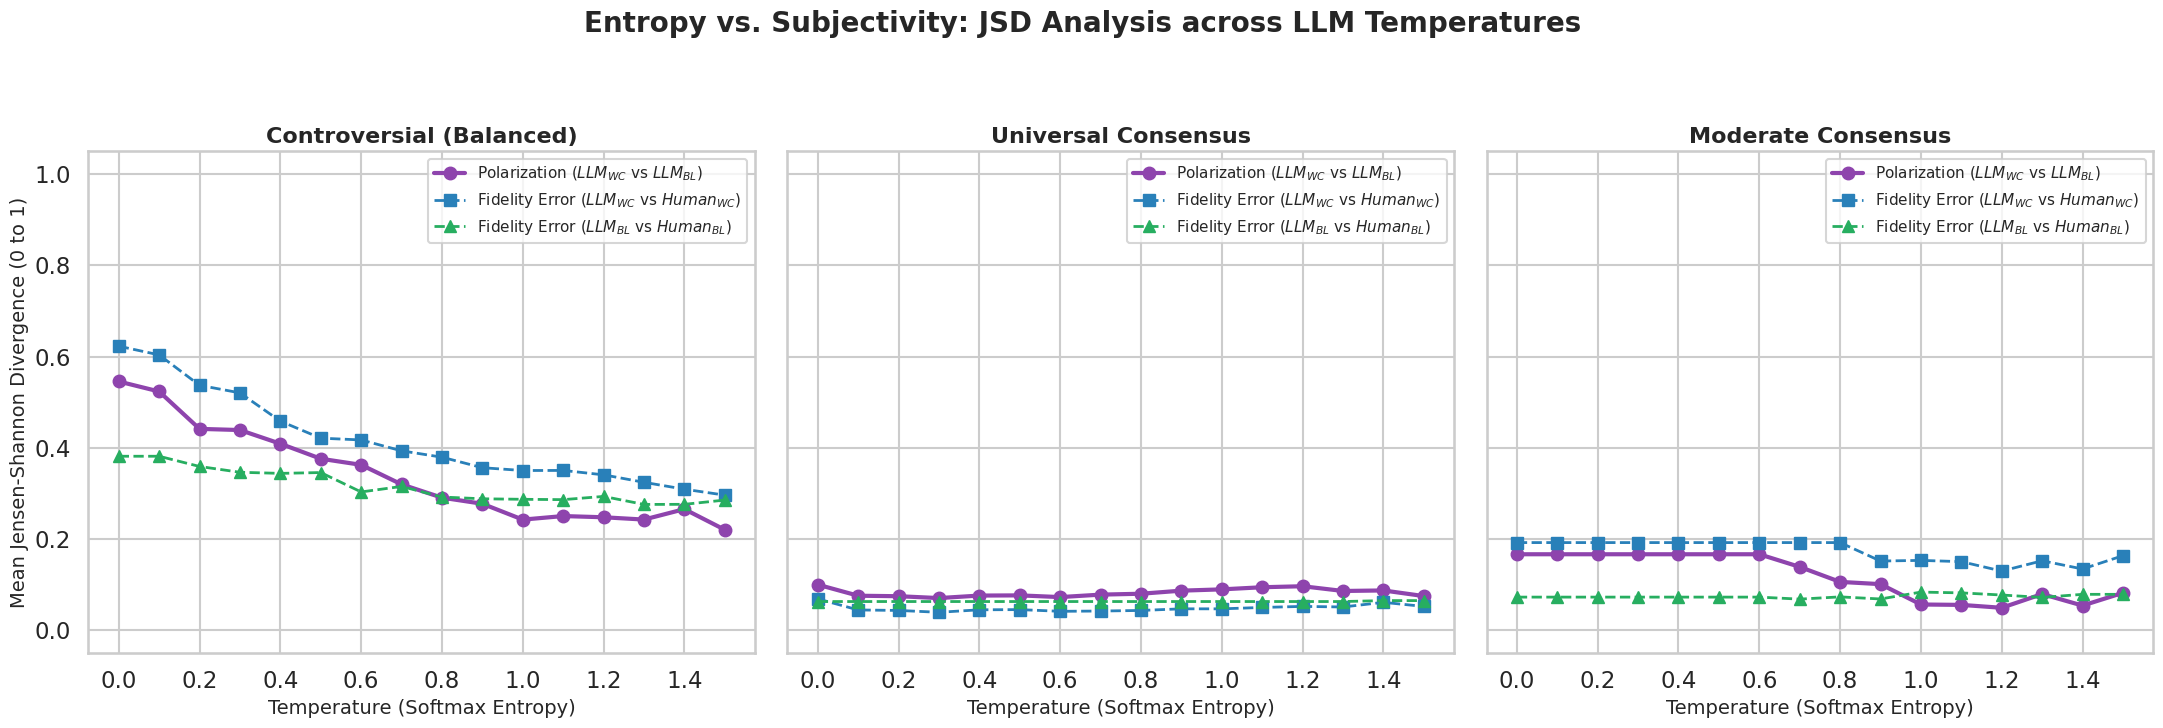

✅ Analysis Complete!


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import jensenshannon

print("--- Computing Comprehensive JSD Metrics across Temperatures ---")

# 1. Math Helper: True Jensen-Shannon Divergence (Bounded 0 to 1)
def calculate_true_jsd(p, q):
    p = np.array(p, dtype=np.float64)
    q = np.array(q, dtype=np.float64)
    
    # Failsafe if the LLM completely broke and returned no valid votes
    if np.sum(p) == 0 or np.sum(q) == 0:
        return np.nan
        
    p = p / np.sum(p)
    q = q / np.sum(q)
    
    # Scipy returns the Distance (sqrt of Divergence). We square it for True JSD.
    return jensenshannon(p, q, base=2) ** 2

# 2. Extractors for Triplets [0, 1, 2]
def get_human_triplet(df, sentence):
    subset = df[df['text'] == sentence]
    if len(subset) == 0:
        return [0.0, 0.0, 0.0]
    counts = subset['hatespeech'].value_counts(normalize=True)
    return [counts.get(0, 0.0), counts.get(1, 0.0), counts.get(2, 0.0)]

def get_llm_triplet(votes_series):
    valid_votes = pd.to_numeric(votes_series, errors='coerce').dropna()
    total = len(valid_votes)
    if total == 0:
        return [0.0, 0.0, 0.0]
    counts = valid_votes.value_counts(normalize=True)
    return [counts.get(0, 0.0), counts.get(1, 0.0), counts.get(2, 0.0)]

# 3. Configuration
TEMPERATURES = [round(x * 0.1, 1) for x in range(16)]

# Your exactly named file prefixes for the 3 categories
CATEGORIES = {
    "Controversial (Balanced)": "llama3_ablation",
    "Universal Consensus": "llama3_consensus_ablation",
    "Moderate Consensus": "llama3_moreorless_consensus_ablation"
}

# Nested dictionary to hold results
results = {cat: {'temps': [], 'pol': [], 'fid_wc': [], 'fid_bl': []} for cat in CATEGORIES.keys()}

# 4. The Main Extraction Loop
for cat_name, prefix in CATEGORIES.items():
    print(f"Processing Category: {cat_name}...")
    
    for temp in TEMPERATURES:
        file_path = f"./llm_data/{prefix}_T{temp}_N50.csv"
        
        try:
            df_llm = pd.read_csv(file_path)
            unique_sentences = df_llm['text'].dropna().unique()
            
            pol_scores, fid_wc_scores, fid_bl_scores = [], [], []
            
            for sentence in unique_sentences:
                # Get LLM Data
                subset = df_llm[df_llm['text'] == sentence]
                llm_wc = get_llm_triplet(subset['whicon_vote'])
                llm_bl = get_llm_triplet(subset['blalib_vote'])
                
                # Get Ground Truth Human Data
                hum_wc = get_human_triplet(white_cons_df, sentence)
                hum_bl = get_human_triplet(black_libs_df, sentence)
                
                # Calculate the 3 JSDs
                pol_jsd = calculate_true_jsd(llm_wc, llm_bl)
                fid_wc_jsd = calculate_true_jsd(llm_wc, hum_wc)
                fid_bl_jsd = calculate_true_jsd(llm_bl, hum_bl)
                
                if not np.isnan(pol_jsd): pol_scores.append(pol_jsd)
                if not np.isnan(fid_wc_jsd): fid_wc_scores.append(fid_wc_jsd)
                if not np.isnan(fid_bl_jsd): fid_bl_scores.append(fid_bl_jsd)
            
            # Record the Temperature Averages
            results[cat_name]['temps'].append(temp)
            results[cat_name]['pol'].append(np.mean(pol_scores) if pol_scores else np.nan)
            results[cat_name]['fid_wc'].append(np.mean(fid_wc_scores) if fid_wc_scores else np.nan)
            results[cat_name]['fid_bl'].append(np.mean(fid_bl_scores) if fid_bl_scores else np.nan)
            
        except FileNotFoundError:
            pass # Fails silently if a temperature CSV isn't downloaded yet

# 5. The Visualization Grid
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
fig.suptitle("Entropy vs. Subjectivity: JSD Analysis across LLM Temperatures", fontsize=20, weight='bold', y=1.05)

for idx, (cat_name, data) in enumerate(results.items()):
    ax = axes[idx]
    
    temps = data['temps']
    if not temps:
        ax.set_title(f"{cat_name}\n(No Data Found)", color='red')
        continue
        
    # Plot the 3 distinct lines
    ax.plot(temps, data['pol'], marker='o', color='#8E44AD', linewidth=3, label="Polarization ($LLM_{WC}$ vs $LLM_{BL}$)")
    ax.plot(temps, data['fid_wc'], marker='s', color='#2980B9', linestyle='--', linewidth=2, label="Fidelity Error ($LLM_{WC}$ vs $Human_{WC}$)")
    ax.plot(temps, data['fid_bl'], marker='^', color='#27AE60', linestyle='--', linewidth=2, label="Fidelity Error ($LLM_{BL}$ vs $Human_{BL}$)")
    
    ax.set_title(cat_name, fontsize=16, weight='bold')
    ax.set_xlabel("Temperature (Softmax Entropy)", fontsize=14)
    if idx == 0:
        ax.set_ylabel("Mean Jensen-Shannon Divergence (0 to 1)", fontsize=14)
        
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

print("✅ Analysis Complete!")

--- Computing 2-Stage Pipeline JSD Metrics ---
Processing Strategy 1: Unconstrained...
Processing Strategy 2: Anchored...


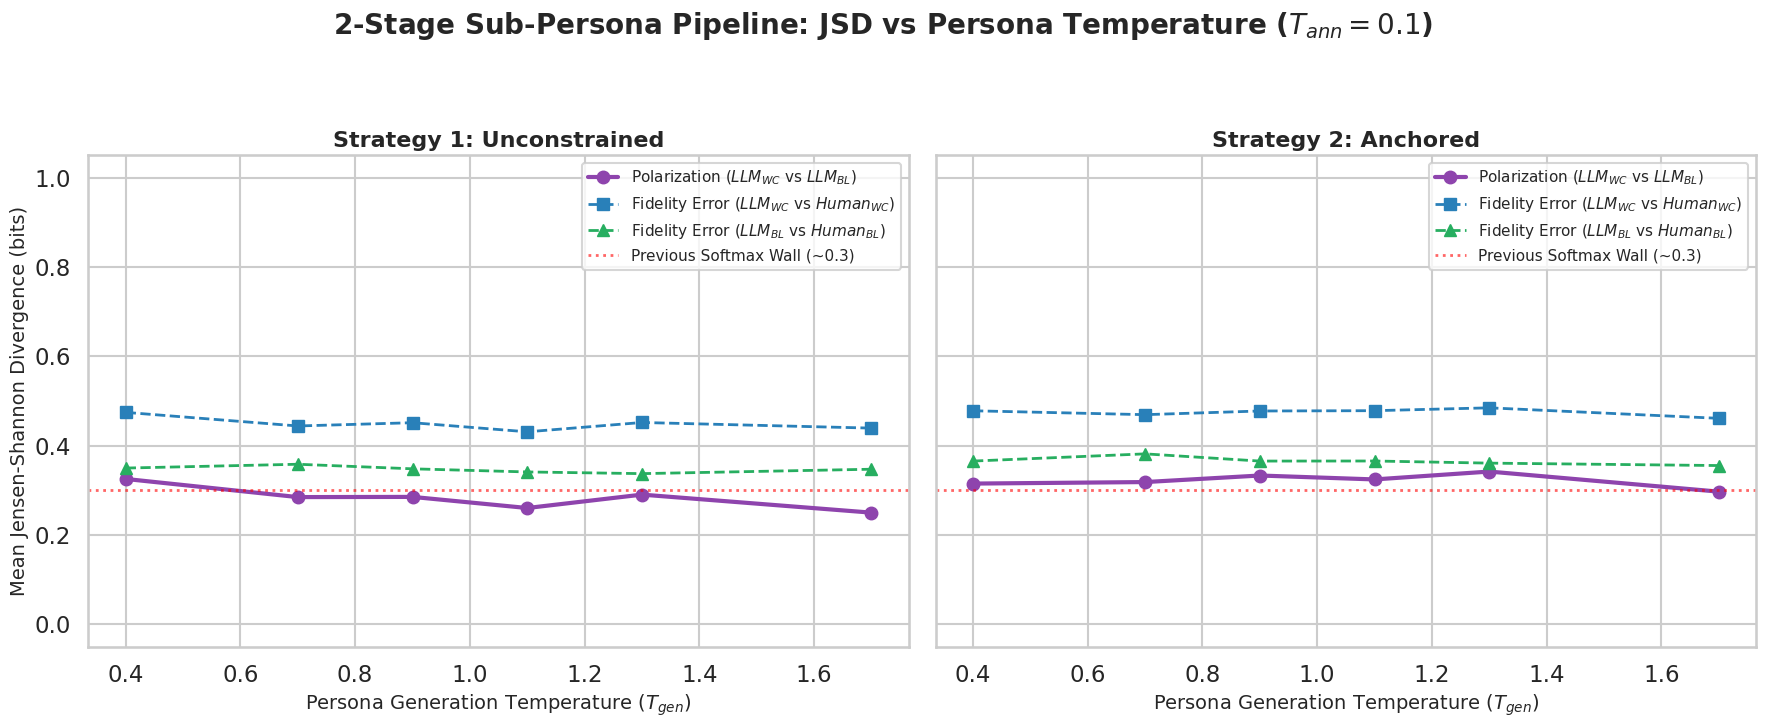

✅ Analysis Complete!


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import jensenshannon

print("--- Computing 2-Stage Pipeline JSD Metrics ---")

# 1. Math Helper: True Jensen-Shannon Divergence (Bits)
def calculate_true_jsd(p, q):
    p = np.array(p, dtype=np.float64)
    q = np.array(q, dtype=np.float64)
    if np.sum(p) == 0 or np.sum(q) == 0:
        return np.nan
    p = p / np.sum(p)
    q = q / np.sum(q)
    return jensenshannon(p, q, base=2) ** 2

# 2. Extractors for Triplets [0, 1, 2]
def get_human_triplet(df, sentence):
    subset = df[df['text'] == sentence]
    if len(subset) == 0:
        return [0.0, 0.0, 0.0]
    counts = subset['hatespeech'].value_counts(normalize=True)
    return [counts.get(0, 0.0), counts.get(1, 0.0), counts.get(2, 0.0)]

def get_llm_triplet(votes_series):
    valid_votes = pd.to_numeric(votes_series, errors='coerce').dropna()
    total = len(valid_votes)
    if total == 0:
        return [0.0, 0.0, 0.0]
    counts = valid_votes.value_counts(normalize=True)
    return [counts.get(0, 0.0), counts.get(1, 0.0), counts.get(2, 0.0)]

# 3. Grid Parameters
T_GEN_LIST = [0.4, 0.7, 0.9, 1.1, 1.3, 1.7]
T_ANN = 0.1
STRATEGIES = {
    1: "Strategy 1: Unconstrained",
    2: "Strategy 2: Anchored"
}

results = {strat: {'t_gen': [], 'pol': [], 'fid_wc': [], 'fid_bl': []} for strat in STRATEGIES.keys()}

# 4. Data Extraction Loop
for strat in STRATEGIES.keys():
    print(f"Processing {STRATEGIES[strat]}...")
    
    for t_gen in T_GEN_LIST:
        file_path = f"./llm_data/llama3_2stage_strat{strat}_Tgen{t_gen}_Tann{T_ANN}_N50.csv"
        
        try:
            df_llm = pd.read_csv(file_path)
            unique_sentences = df_llm['text'].dropna().unique()
            
            pol_scores, fid_wc_scores, fid_bl_scores = [], [], []
            
            for sentence in unique_sentences:
                subset = df_llm[df_llm['text'] == sentence]
                llm_wc = get_llm_triplet(subset['whicon_vote'])
                llm_bl = get_llm_triplet(subset['blalib_vote'])
                
                hum_wc = get_human_triplet(white_cons_df, sentence)
                hum_bl = get_human_triplet(black_libs_df, sentence)
                
                pol_jsd = calculate_true_jsd(llm_wc, llm_bl)
                fid_wc_jsd = calculate_true_jsd(llm_wc, hum_wc)
                fid_bl_jsd = calculate_true_jsd(llm_bl, hum_bl)
                
                if not np.isnan(pol_jsd): pol_scores.append(pol_jsd)
                if not np.isnan(fid_wc_jsd): fid_wc_scores.append(fid_wc_jsd)
                if not np.isnan(fid_bl_jsd): fid_bl_scores.append(fid_bl_jsd)
            
            results[strat]['t_gen'].append(t_gen)
            results[strat]['pol'].append(np.mean(pol_scores) if pol_scores else np.nan)
            results[strat]['fid_wc'].append(np.mean(fid_wc_scores) if fid_wc_scores else np.nan)
            results[strat]['fid_bl'].append(np.mean(fid_bl_scores) if fid_bl_scores else np.nan)
            
        except FileNotFoundError:
            print(f"  └─ Missing file: {file_path}")

# 5. Visualization
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
fig.suptitle(f"2-Stage Sub-Persona Pipeline: JSD vs Persona Temperature ($T_{{ann}}={T_ANN}$)", fontsize=20, weight='bold', y=1.05)

for idx, (strat, name) in enumerate(STRATEGIES.items()):
    ax = axes[idx]
    data = results[strat]
    
    if not data['t_gen']:
        ax.set_title(f"{name}\n(No Data Found)", color='red')
        continue
        
    ax.plot(data['t_gen'], data['pol'], marker='o', color='#8E44AD', linewidth=3, label="Polarization ($LLM_{WC}$ vs $LLM_{BL}$)")
    ax.plot(data['t_gen'], data['fid_wc'], marker='s', color='#2980B9', linestyle='--', linewidth=2, label="Fidelity Error ($LLM_{WC}$ vs $Human_{WC}$)")
    ax.plot(data['t_gen'], data['fid_bl'], marker='^', color='#27AE60', linestyle='--', linewidth=2, label="Fidelity Error ($LLM_{BL}$ vs $Human_{BL}$)")
    
    ax.set_title(name, fontsize=16, weight='bold')
    ax.set_xlabel("Persona Generation Temperature ($T_{gen}$)", fontsize=14)
    if idx == 0:
        ax.set_ylabel("Mean Jensen-Shannon Divergence (bits)", fontsize=14)
        
    # Adding a reference line for the old "0.3 Softmax Wall"
    ax.axhline(y=0.3, color='red', linestyle=':', alpha=0.6, linewidth=2, label="Previous Softmax Wall (~0.3)")
    
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

print("✅ Analysis Complete!")

In [18]:
import pandas as pd

# --- CONFIGURATION ---
# Choose which specific run you want to inspect
STRATEGY = 2        # 1 (Unconstrained) or 2 (Anchored)
T_GEN = 0.9         # The Persona Temperature you want to look at
T_ANN = 0.1         # The locked classification temperature
# ---------------------

file_path = f"./llm_data/llama3_2stage_strat{STRATEGY}_Tgen{T_GEN}_Tann{T_ANN}_N50.csv"

def get_human_triplet(df, sentence):
    subset = df[df['text'] == sentence]
    if len(subset) == 0:
        return [0.0, 0.0, 0.0]
    counts = subset['hatespeech'].value_counts(normalize=True)
    return [round(counts.get(0, 0.0), 2), round(counts.get(1, 0.0), 2), round(counts.get(2, 0.0), 2)]

def get_llm_triplet(votes_series):
    valid_votes = pd.to_numeric(votes_series, errors='coerce').dropna()
    total = len(valid_votes)
    if total == 0:
        return [0.0, 0.0, 0.0]
    counts = valid_votes.value_counts(normalize=True)
    return [round(counts.get(0, 0.0), 2), round(counts.get(1, 0.0), 2), round(counts.get(2, 0.0), 2)]

try:
    df_llm = pd.read_csv(file_path)
    unique_sentences = df_llm['text'].dropna().unique()
    
    print(f"🔍 INSPECTING DISTRIBUTIONS | Strat: {STRATEGY} | T_gen: {T_GEN}")
    print("Format: [ % Not Hate (0), % Hate (1), % Extreme (2) ]")
    print("=" * 85)
    
    for idx, sentence in enumerate(unique_sentences):
        # LLM Data
        subset = df_llm[df_llm['text'] == sentence]
        llm_wc = get_llm_triplet(subset['whicon_vote'])
        llm_bl = get_llm_triplet(subset['blalib_vote'])
        
        # Human Data
        hum_wc = get_human_triplet(white_cons_df, sentence)
        hum_bl = get_human_triplet(black_libs_df, sentence)
        
        # Truncate sentence for clean printing
        short_sent = sentence[:70].replace('\n', ' ').replace('\r', '') + "..."
        
        print(f"\nText {idx+1}: {short_sent}")
        print(f"  White Cons -> HUMAN: {hum_wc}  |  LLM: {llm_wc}")
        print(f"  Black Libs -> HUMAN: {hum_bl}  |  LLM: {llm_bl}")

except FileNotFoundError:
    print(f"❌ Error: Could not find {file_path}. Check your STRATEGY and T_GEN variables.")

🔍 INSPECTING DISTRIBUTIONS | Strat: 2 | T_gen: 0.9
Format: [ % Not Hate (0), % Hate (1), % Extreme (2) ]

Text 1: Who hurt you? Lol. It's comical how stupid and angry you people are.  ...
  White Cons -> HUMAN: [np.float64(0.49), np.float64(0.08), np.float64(0.42)]  |  LLM: [0.0, np.float64(0.5), np.float64(0.5)]
  Black Libs -> HUMAN: [np.float64(0.59), np.float64(0.06), np.float64(0.35)]  |  LLM: [0.0, 0.0, np.float64(1.0)]

Text 2: RT @JihadistJoe: We Muslims have no military honour whatsoever, we are...
  White Cons -> HUMAN: [np.float64(0.43), np.float64(0.08), np.float64(0.49)]  |  LLM: [0.0, np.float64(0.54), np.float64(0.46)]
  Black Libs -> HUMAN: [np.float64(0.24), np.float64(0.1), np.float64(0.67)]  |  LLM: [0.0, 0.0, np.float64(1.0)]

Text 3: im ,i hate black people and minorities...
  White Cons -> HUMAN: [np.float64(0.58), 0.0, np.float64(0.42)]  |  LLM: [0.0, 0.0, np.float64(1.0)]
  Black Libs -> HUMAN: [np.float64(0.64), 0.0, np.float64(0.36)]  |  LLM: [0.0, 0.0, np.flo

## Going to Binary

At this point I looked at the generated annotation, and noted that the LLM instances were overvoting 1 and 2, while humans were more cautious on voting 2. That is why I switched to binary voting, and a different prompting strategy.

Processing binary_data4 (Aggressive Prompt)...


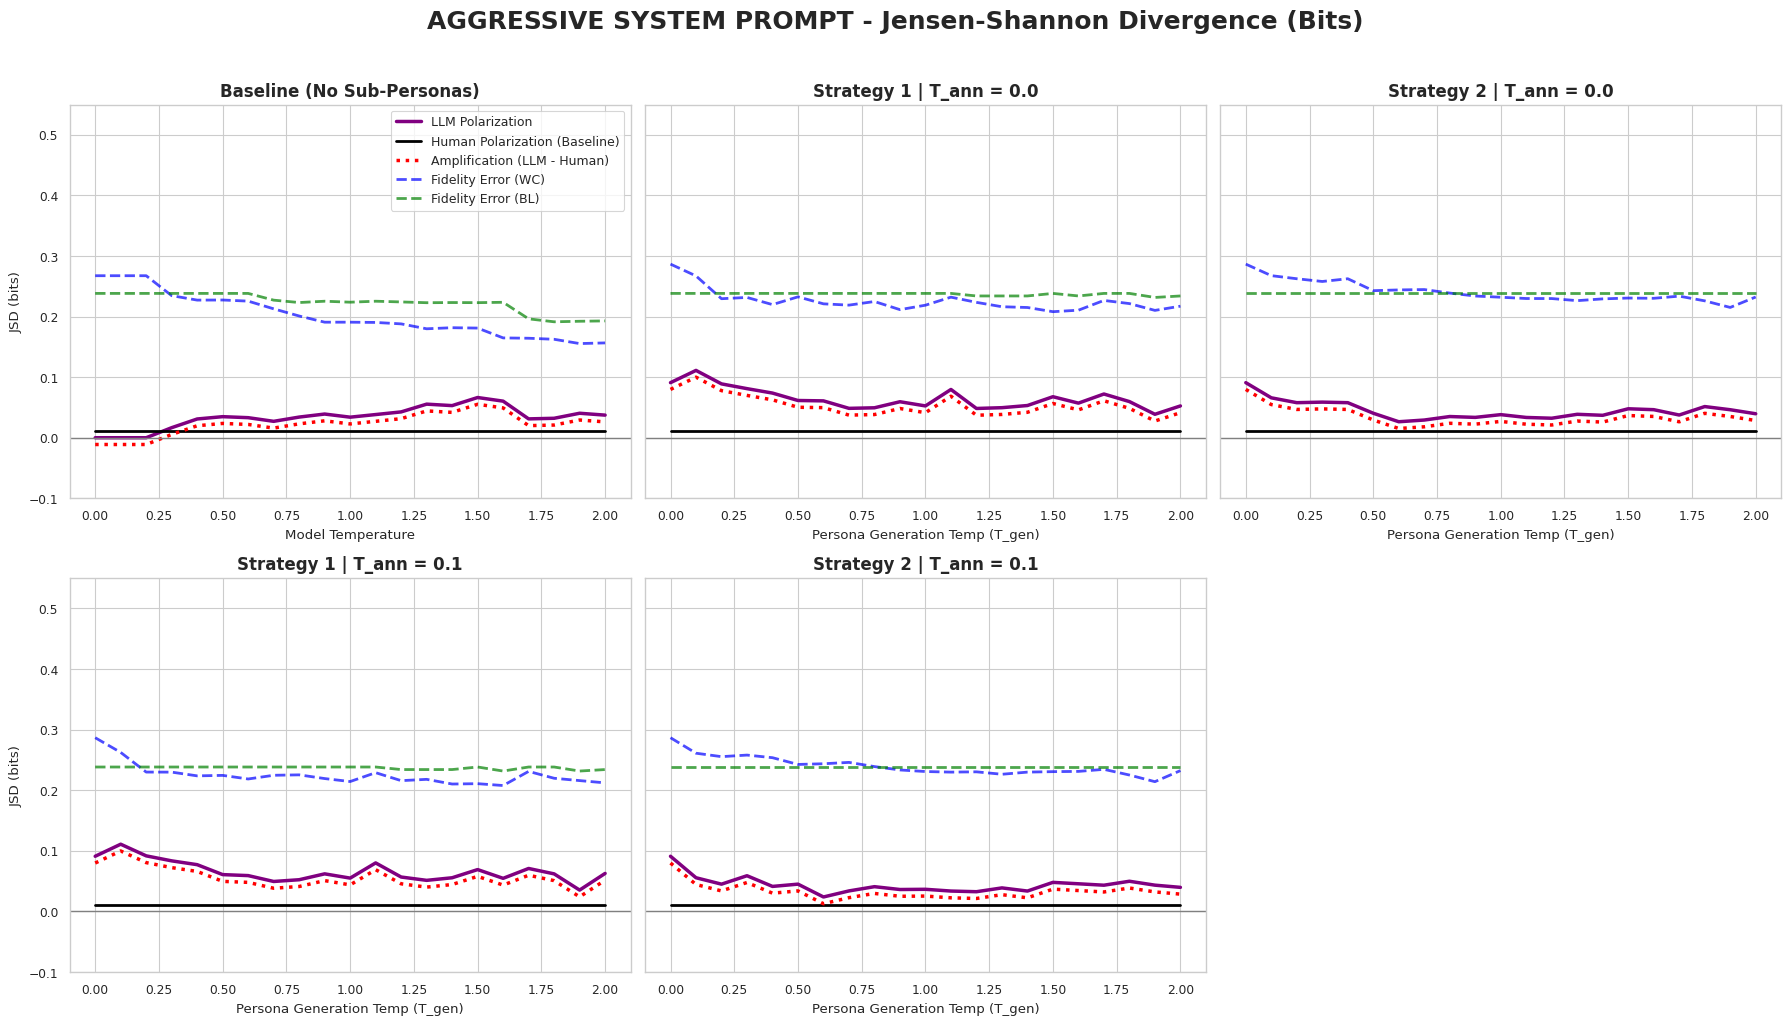

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import jensenshannon
import os

# --- 1. ROBUST MATH FUNCTIONS ---
def get_binary_dist_from_votes(votes_series):
    valid = pd.to_numeric(votes_series, errors='coerce').dropna()
    valid = valid[valid.isin([0, 1])] 
    if len(valid) == 0:
        return None, 0
    counts = valid.value_counts(normalize=True)
    return [counts.get(0, 0.0), counts.get(1, 0.0)], len(valid)

def calculate_true_jsd(p, q):
    if p is None or q is None:
        return np.nan
    p, q = np.array(p, dtype=np.float64), np.array(q, dtype=np.float64)
    if p.sum() == 0 or q.sum() == 0:
        return np.nan
    p, q = p / p.sum(), q / q.sum()
    return jensenshannon(p, q, base=2) ** 2

def analyze_binary_dataset(df_llm, df_human_wc, df_human_bl):
    rows = []
    
    # Ensure binary target exists in human data
    if 'is_hate_speech_binary' not in df_human_wc.columns:
        df_human_wc['is_hate_speech_binary'] = (df_human_wc['hatespeech'] > 0).astype(int)
        df_human_bl['is_hate_speech_binary'] = (df_human_bl['hatespeech'] > 0).astype(int)

    for sentence in df_llm['text'].dropna().unique():
        llm_subset = df_llm[df_llm['text'] == sentence]
        hum_wc_subset = df_human_wc[df_human_wc['text'] == sentence]
        hum_bl_subset = df_human_bl[df_human_bl['text'] == sentence]
        
        llm_wc, _ = get_binary_dist_from_votes(llm_subset['whicon_vote'])
        llm_bl, _ = get_binary_dist_from_votes(llm_subset['blalib_vote'])
        hum_wc, _ = get_binary_dist_from_votes(hum_wc_subset['is_hate_speech_binary'])
        hum_bl, _ = get_binary_dist_from_votes(hum_bl_subset['is_hate_speech_binary'])
        
        if hum_wc is None or hum_bl is None:
            continue
            
        pol_llm = calculate_true_jsd(llm_wc, llm_bl)
        pol_hum = calculate_true_jsd(hum_wc, hum_bl)
        
        rows.append({
            "fid_wc": calculate_true_jsd(llm_wc, hum_wc),
            "fid_bl": calculate_true_jsd(llm_bl, hum_bl),
            "pol_llm": pol_llm,
            "pol_hum": pol_hum,
            "amplification": pol_llm - pol_hum if not np.isnan(pol_llm) and not np.isnan(pol_hum) else np.nan
        })
        
    results_df = pd.DataFrame(rows)
    return results_df.mean().to_dict() if len(results_df) > 0 else None

# --- 2. PLOTTING FUNCTION ---
def plot_5_panels(data_dict, title_prefix):
    sns.set_theme(style="whitegrid", context="paper")
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
    fig.suptitle(f"{title_prefix} - Jensen-Shannon Divergence (Bits)", fontsize=18, weight='bold', y=1.02)
    axes = axes.flatten()
    
    plot_configs = [
        ('baseline', 'Baseline (No Sub-Personas)', 'Model Temperature'),
        ('strat1_Tann0.0', 'Strategy 1 | T_ann = 0.0', 'Persona Generation Temp (T_gen)'),
        ('strat2_Tann0.0', 'Strategy 2 | T_ann = 0.0', 'Persona Generation Temp (T_gen)'),
        ('strat1_Tann0.1', 'Strategy 1 | T_ann = 0.1', 'Persona Generation Temp (T_gen)'),
        ('strat2_Tann0.1', 'Strategy 2 | T_ann = 0.1', 'Persona Generation Temp (T_gen)')
    ]
    
    for idx, (key, title, xlabel) in enumerate(plot_configs):
        ax = axes[idx]
        df_plot = pd.DataFrame(data_dict[key]).dropna(subset=['pol_llm'])
        
        if df_plot.empty:
            ax.set_title(f"{title}\n[No Data]", color='red')
            continue
            
        ax.plot(df_plot['temp'], df_plot['pol_llm'], color='purple', linewidth=2.5, label='LLM Polarization')
        ax.plot(df_plot['temp'], df_plot['pol_hum'], color='black', linewidth=2, label='Human Polarization (Baseline)')
        ax.plot(df_plot['temp'], df_plot['amplification'], color='red', linestyle=':', linewidth=2.5, label='Amplification (LLM - Human)')
        ax.plot(df_plot['temp'], df_plot['fid_wc'], color='blue', linestyle='--', linewidth=2, alpha=0.7, label='Fidelity Error (WC)')
        ax.plot(df_plot['temp'], df_plot['fid_bl'], color='green', linestyle='--', linewidth=2, alpha=0.7, label='Fidelity Error (BL)')
        
        ax.set_title(title, fontsize=12, weight='bold')
        ax.set_xlabel(xlabel)
        if idx % 3 == 0:
            ax.set_ylabel("JSD (bits)")
        ax.set_ylim(-0.1, 0.55)
        ax.axhline(0, color='gray', linewidth=1)
        
    axes[0].legend(loc='upper right', fontsize=9)
    fig.delaxes(axes[5]) # Remove the 6th empty subplot
    plt.tight_layout()
    plt.show()

# --- 3. DATA EXTRACTION: BINARY_DATA4 (AGGRESSIVE) ---
folder_4 = "./binary_data4"
temps = [round(x * 0.1, 1) for x in range(21)]

data_4 = {
    'baseline': [], 'strat1_Tann0.0': [], 'strat2_Tann0.0': [], 
    'strat1_Tann0.1': [], 'strat2_Tann0.1': []
}

print("Processing binary_data4 (Aggressive Prompt)...")
for t in temps:
    # 1. Baseline
    file_base = f"{folder_4}/llama3_binary_baseline_aggressive_T{t}_N50.csv"
    if os.path.exists(file_base):
        res = analyze_binary_dataset(pd.read_csv(file_base), white_cons_df, black_libs_df)
        if res: data_4['baseline'].append({'temp': t, **res})
            
    # 2-Stage Grids
    for s in [1, 2]:
        for ta in [0.0, 0.1]:
            file_grid = f"{folder_4}/llama3_binary_2stage_aggressive_strat{s}_Tgen{t}_Tann{ta}_N50.csv"
            key = f"strat{s}_Tann{ta}"
            if os.path.exists(file_grid):
                res = analyze_binary_dataset(pd.read_csv(file_grid), white_cons_df, black_libs_df)
                if res: data_4[key].append({'temp': t, **res})

plot_5_panels(data_4, "AGGRESSIVE SYSTEM PROMPT")

Processing binary_data2 (Sandwiched Prompt)...


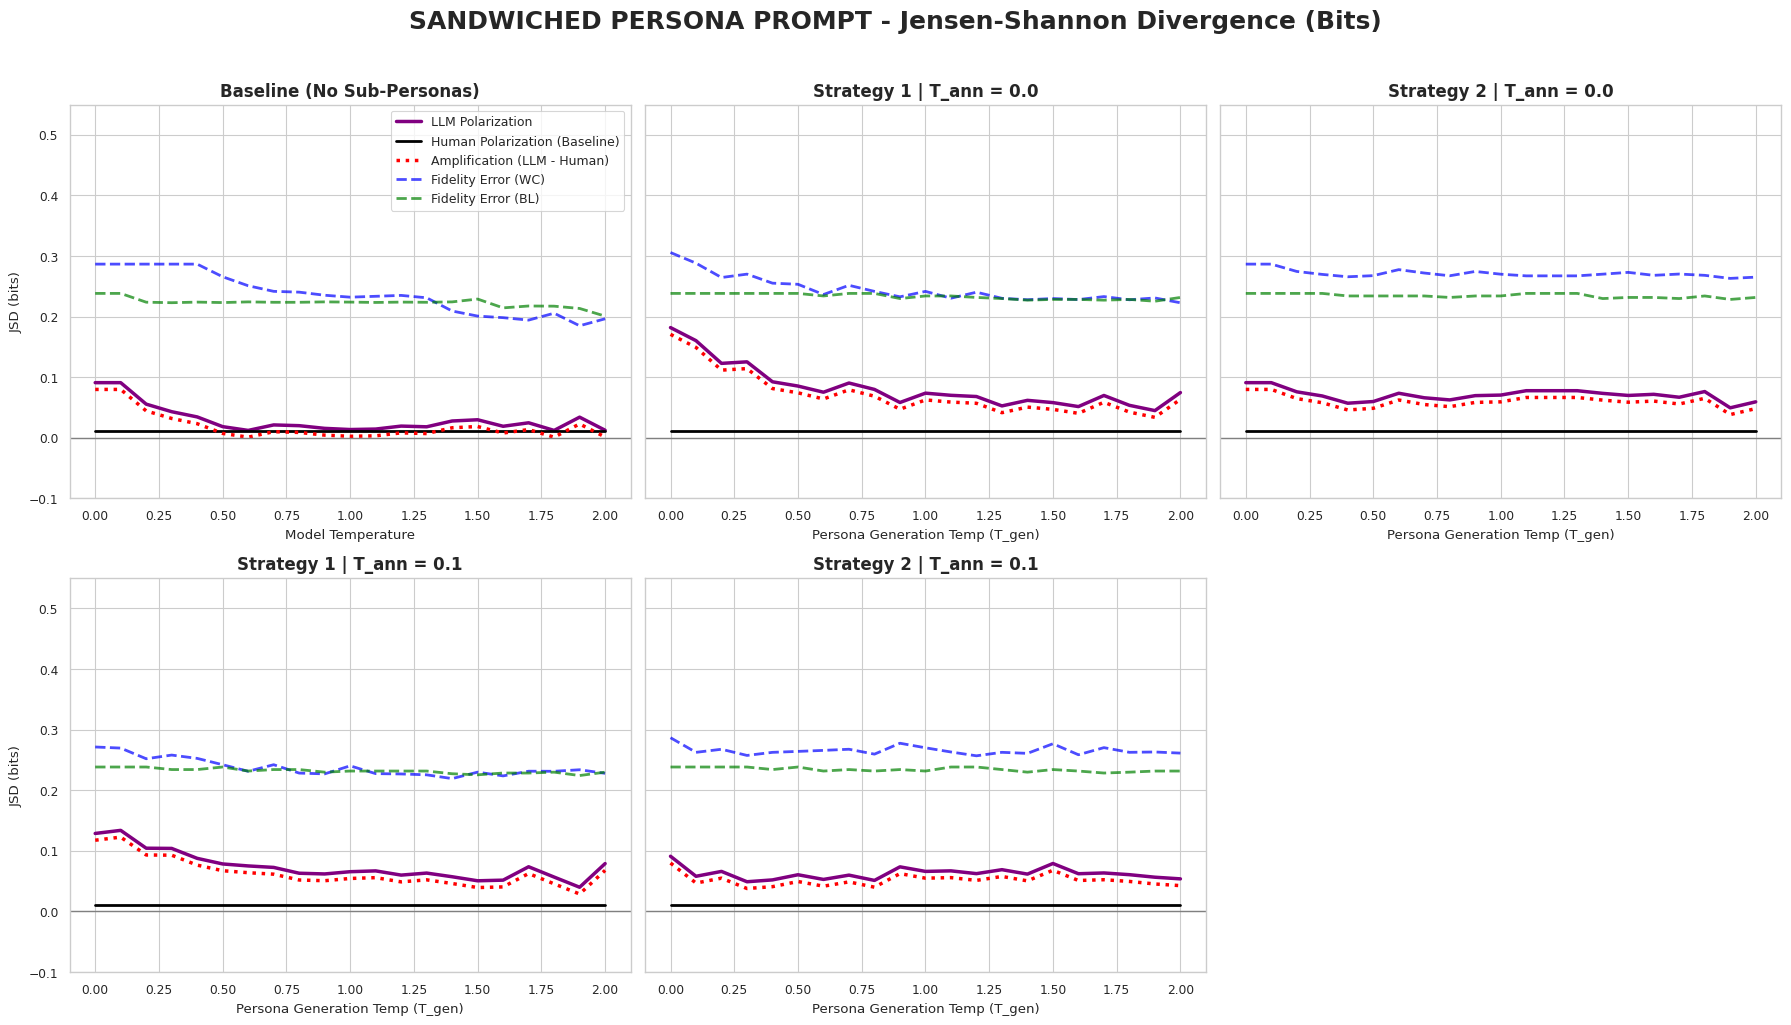

In [20]:
# --- 4. DATA EXTRACTION: BINARY_DATA2 (SANDWICHED) ---
folder_2 = "./binary_data2"

data_2 = {
    'baseline': [], 'strat1_Tann0.0': [], 'strat2_Tann0.0': [], 
    'strat1_Tann0.1': [], 'strat2_Tann0.1': []
}

print("Processing binary_data2 (Sandwiched Prompt)...")
for t in temps:
    # 1. Baseline (Standard naming)
    file_base = f"{folder_2}/llama3_binary_baseline_T{t}_N50.csv"
    if os.path.exists(file_base):
        res = analyze_binary_dataset(pd.read_csv(file_base), white_cons_df, black_libs_df)
        if res: data_2['baseline'].append({'temp': t, **res})
            
    # 2-Stage Grids (Standard naming)
    for s in [1, 2]:
        for ta in [0.0, 0.1]:
            file_grid = f"{folder_2}/llama3_binary_2stage_strat{s}_Tgen{t}_Tann{ta}_N50.csv"
            key = f"strat{s}_Tann{ta}"
            if os.path.exists(file_grid):
                res = analyze_binary_dataset(pd.read_csv(file_grid), white_cons_df, black_libs_df)
                if res: data_2[key].append({'temp': t, **res})

plot_5_panels(data_2, "SANDWICHED PERSONA PROMPT")

Processing data_binary3 (Base Model with Few-Shot Prompt)...


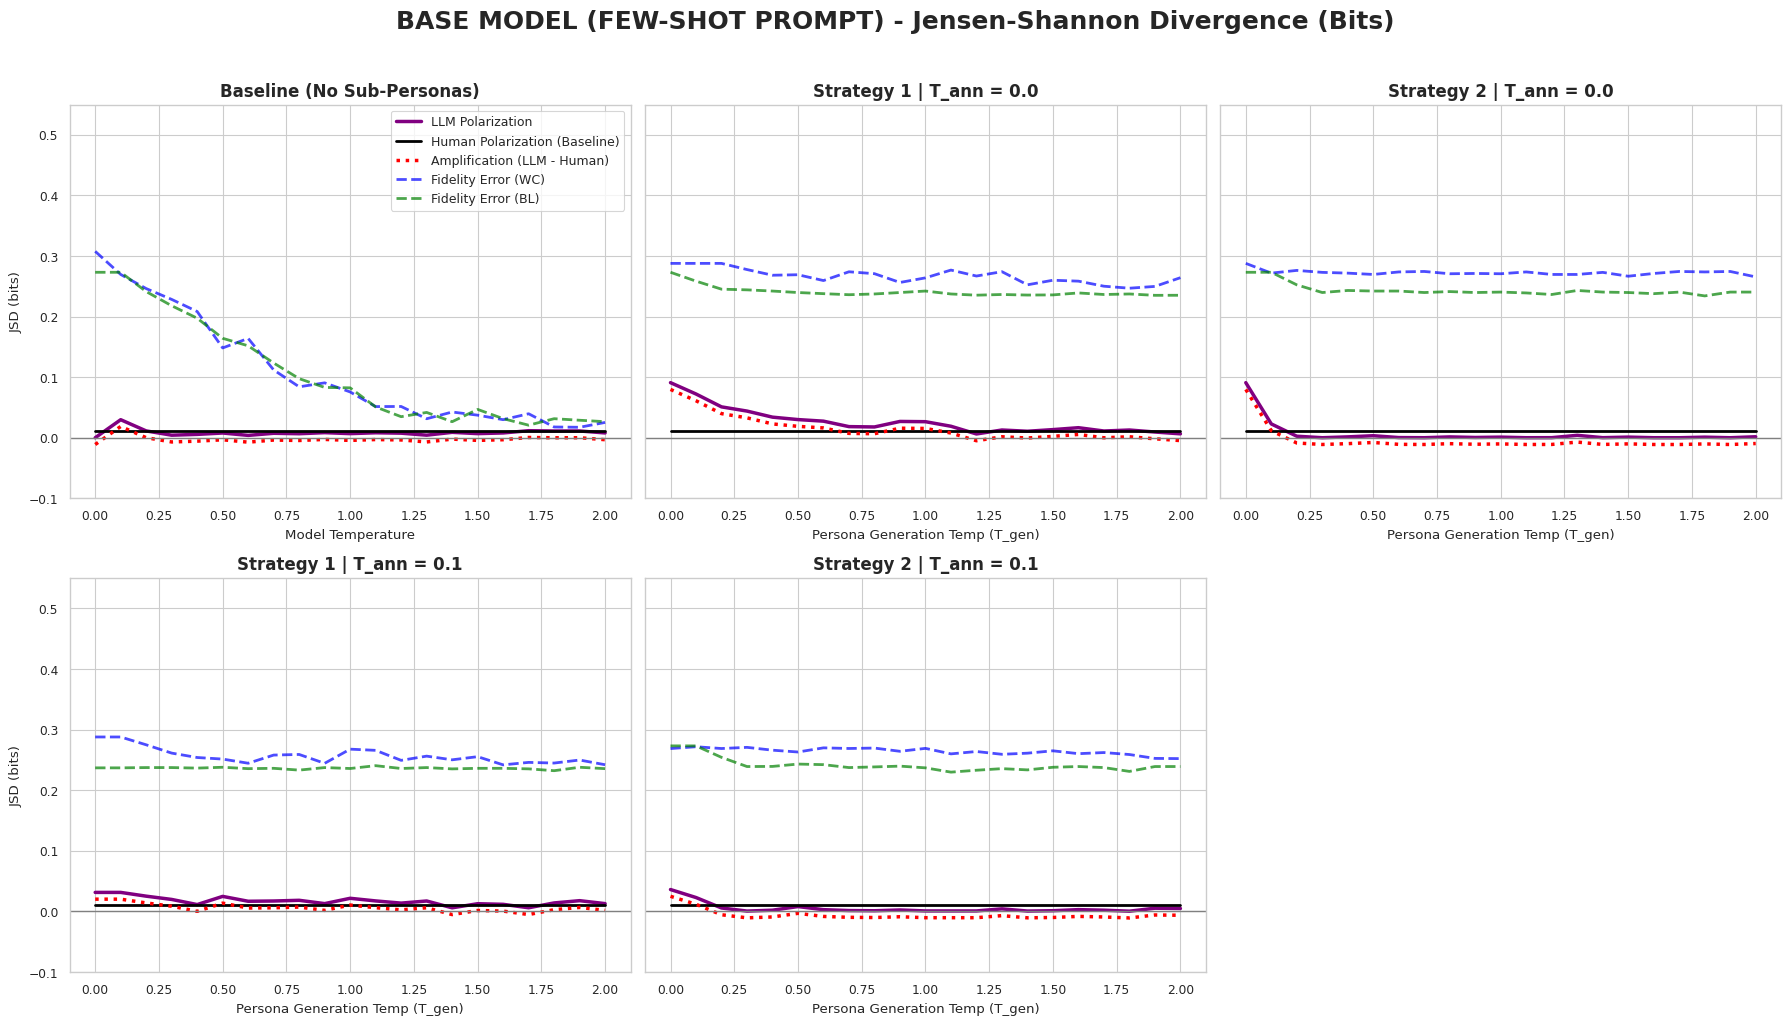

In [21]:
# --- 5. DATA EXTRACTION: DATA_BINARY3 (BASE MODEL) ---
folder_3 = "./data_binary3"
temps = [round(x * 0.1, 1) for x in range(21)]

data_3 = {
    'baseline': [], 'strat1_Tann0.0': [], 'strat2_Tann0.0': [], 
    'strat1_Tann0.1': [], 'strat2_Tann0.1': []
}

print("Processing data_binary3 (Base Model with Few-Shot Prompt)...")
for t in temps:
    # 1. Baseline (Base model naming)
    file_base = f"{folder_3}/llama3_base_binary_baseline_T{t}_N50.csv"
    if os.path.exists(file_base):
        res = analyze_binary_dataset(pd.read_csv(file_base), white_cons_df, black_libs_df)
        if res: data_3['baseline'].append({'temp': t, **res})
            
    # 2-Stage Grids (Base model naming)
    for s in [1, 2]:
        for ta in [0.0, 0.1]:
            file_grid = f"{folder_3}/llama3_base_binary_2stage_strat{s}_Tgen{t}_Tann{ta}_N50.csv"
            key = f"strat{s}_Tann{ta}"
            if os.path.exists(file_grid):
                res = analyze_binary_dataset(pd.read_csv(file_grid), white_cons_df, black_libs_df)
                if res: data_3[key].append({'temp': t, **res})

plot_5_panels(data_3, "BASE MODEL (FEW-SHOT PROMPT)")

In [22]:
import pandas as pd

# --- CONFIGURATION ---
T_PARAM = 0.7         # Set the LLM temperature you want to inspect (e.g., 0.0, 0.5, 1.0)
NUM_SENTENCES = 10    # How many sentences to print
# ---------------------

file_path = f"./data_binary3/llama3_base_binary_baseline_T{T_PARAM}_N50.csv"

def get_human_binary(df, sentence):
    """Safely extracts human binary distribution."""
    subset = df[df['text'] == sentence]
    if len(subset) == 0:
        return "[ Missing ]"
    is_hate = (subset['hatespeech'] > 0).astype(int)
    counts = is_hate.value_counts(normalize=True)
    return [round(counts.get(0, 0.0), 2), round(counts.get(1, 0.0), 2)]

def get_llm_binary(votes_series):
    """Safely extracts LLM binary distribution."""
    valid = pd.to_numeric(votes_series, errors='coerce').dropna()
    valid = valid[valid.isin([0, 1])]
    if len(valid) == 0:
        return "[ Missing / No Valid Votes ]"
    counts = valid.value_counts(normalize=True)
    return [round(counts.get(0, 0.0), 2), round(counts.get(1, 0.0), 2)]

try:
    df_llm = pd.read_csv(file_path)
    unique_sentences = df_llm['text'].dropna().unique()
    
    print(f"🔍 INSPECTING BASE MODEL BASELINE | T = {T_PARAM}")
    print("Format: [ % Not Hate (0), % Hate (1) ]")
    print("=" * 85)
    
    for idx, sentence in enumerate(unique_sentences[:NUM_SENTENCES]):
        llm_subset = df_llm[df_llm['text'] == sentence]
        
        # LLM Distributions
        llm_wc = get_llm_binary(llm_subset['whicon_vote'])
        llm_bl = get_llm_binary(llm_subset['blalib_vote'])
        
        # Human Distributions
        hum_wc = get_human_binary(white_cons_df, sentence)
        hum_bl = get_human_binary(black_libs_df, sentence)
        
        short_sent = sentence[:75].replace('\n', ' ').replace('\r', '') + "..."
        
        print(f"\nText {idx+1}: {short_sent}")
        print(f"  White Cons -> HUMAN: {hum_wc}  |  LLM: {llm_wc}")
        print(f"  Black Libs -> HUMAN: {hum_bl}  |  LLM: {llm_bl}")

except FileNotFoundError:
    print(f"❌ Error: Could not find {file_path}. Are you sure it finished running?")

🔍 INSPECTING BASE MODEL BASELINE | T = 0.7
Format: [ % Not Hate (0), % Hate (1) ]

Text 1: Who hurt you? Lol. It's comical how stupid and angry you people are.  MEH A...
  White Cons -> HUMAN: [np.float64(0.49), np.float64(0.51)]  |  LLM: [np.float64(0.78), np.float64(0.22)]
  Black Libs -> HUMAN: [np.float64(0.59), np.float64(0.41)]  |  LLM: [np.float64(0.78), np.float64(0.22)]

Text 2: RT @JihadistJoe: We Muslims have no military honour whatsoever, we are sub ...
  White Cons -> HUMAN: [np.float64(0.43), np.float64(0.57)]  |  LLM: [np.float64(0.22), np.float64(0.78)]
  Black Libs -> HUMAN: [np.float64(0.24), np.float64(0.76)]  |  LLM: [np.float64(0.16), np.float64(0.84)]

Text 3: im ,i hate black people and minorities...
  White Cons -> HUMAN: [np.float64(0.58), np.float64(0.42)]  |  LLM: [0.0, np.float64(1.0)]
  Black Libs -> HUMAN: [np.float64(0.64), np.float64(0.36)]  |  LLM: [0.0, np.float64(1.0)]

Text 4: My God look at these BARBARIC PPL. And these pigs all watching. They r a v

Now let's check what the Base model does on the consensus sentences

Processing data_base_consensus (The Diagnostic Run)...


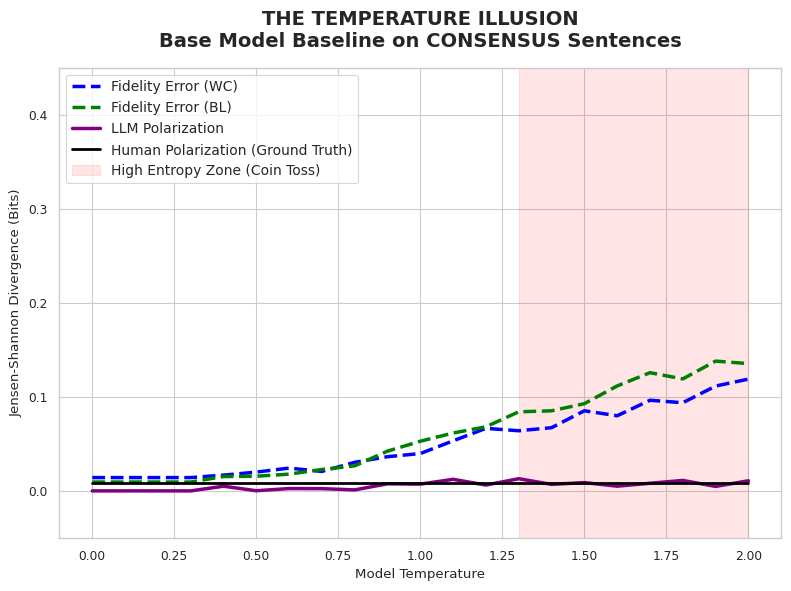

In [23]:
# --- 6. DATA EXTRACTION: DATA_BASE_CONSENSUS ---
folder_cons = "./data_base_consensus"
temps = [round(x * 0.1, 1) for x in range(21)]

data_cons = []

print("Processing data_base_consensus (The Diagnostic Run)...")
for t in temps:
    file_cons = f"{folder_cons}/llama3_base_consensus_T{t}_N50.csv"
    if os.path.exists(file_cons):
        df_llm_cons = pd.read_csv(file_cons)
        res = analyze_binary_dataset(df_llm_cons, white_cons_df, black_libs_df)
        if res: 
            data_cons.append({'temp': t, **res})

df_cons_plot = pd.DataFrame(data_cons)

# --- 7. PLOTTING THE DIAGNOSTIC ---
if not df_cons_plot.empty:
    plt.figure(figsize=(8, 6))
    sns.set_theme(style="whitegrid", context="paper")
    
    # Plot the lines
    plt.plot(df_cons_plot['temp'], df_cons_plot['fid_wc'], color='blue', linestyle='--', linewidth=2.5, label='Fidelity Error (WC)')
    plt.plot(df_cons_plot['temp'], df_cons_plot['fid_bl'], color='green', linestyle='--', linewidth=2.5, label='Fidelity Error (BL)')
    plt.plot(df_cons_plot['temp'], df_cons_plot['pol_llm'], color='purple', linewidth=2.5, label='LLM Polarization')
    plt.plot(df_cons_plot['temp'], df_cons_plot['pol_hum'], color='black', linewidth=2, label='Human Polarization (Ground Truth)')
    
    plt.title("THE TEMPERATURE ILLUSION\nBase Model Baseline on CONSENSUS Sentences", fontsize=14, weight='bold', pad=15)
    plt.xlabel("Model Temperature")
    plt.ylabel("Jensen-Shannon Divergence (Bits)")
    plt.ylim(-0.05, 0.45)
    
    # Add a visual marker for where the "illusion" starts taking over
    plt.axvspan(1.3, 2.0, color='red', alpha=0.1, label="High Entropy Zone (Coin Toss)")
    
    plt.legend(loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("❌ No data found. Make sure the CSVs are inside './data_base_consensus/'")

# Plots for presentation


In [41]:
import matplotlib.pyplot as plt
import pandas as pd

# Enable dark background styling
#plt.style.use('dark_background')

def plot_base_baseline_fidelity(data_dict, filename="slide_base_fidelity.png"):
    # Extract just the baseline data
    df_plot = pd.DataFrame(data_dict['baseline']).dropna(subset=['fid_wc', 'fid_bl'])
    
    if df_plot.empty:
        print("No baseline data found to plot!")
        return
        
    # Set dimensions to be slightly wider than tall
    fig, ax = plt.subplots(figsize=(7, 4.5))
    
    # Plot the two fidelity lines
    # Using bright blue and green for high visibility on dark backgrounds
    ax.plot(df_plot['temp'], df_plot['fid_wc'], color='#4da6ff', linestyle='--', linewidth=2.5, label='Fidelity Error (WC)')
    ax.plot(df_plot['temp'], df_plot['fid_bl'], color='#39ff14', linestyle='--', linewidth=2.5, label='Fidelity Error (BL)')
    
    # Formatting
    ax.set_title('Base Model (Baseline): Fidelity Error vs. Temperature', fontsize=14, weight='bold', pad=15, color='yellow')
    ax.set_xlabel('Model Temperature', fontsize=12, weight='bold', color='yellow')
    ax.set_ylabel('JSD (bits)', fontsize=12, weight='bold', color='yellow')
    
    # Clean up spines for a sleek, modern look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#555555')
    ax.spines['bottom'].set_color('#555555')
    
    # Set y-axis limits and add a subtle zero line
    ax.set_ylim(-0.05, 0.50)
    ax.axhline(0, color='#555555', linewidth=1)
    
    ax.tick_params(axis='x', colors='white', labelsize=11)
    ax.tick_params(axis='y', colors='white', labelsize=11)
    
    ax.legend(loc='upper right', fontsize=11, frameon=False, labelcolor='white')
    
    # Save the plot with a transparent background
    plt.tight_layout()
    plt.savefig(filename, transparent=True, dpi=300)
    plt.close()
    
    print(f"Plot successfully saved as '{filename}'")

# Call the function using your existing data_3 dictionary
plot_base_baseline_fidelity(data_3)

Plot successfully saved as 'slide_base_fidelity.png'


In [42]:
import matplotlib.pyplot as plt
import pandas as pd

# Enable dark background styling
plt.style.use('dark_background')

def plot_consensus_diagnostic_clean(data_list, filename="slide_consensus_diagnostic.png"):
    df_plot = pd.DataFrame(data_list)
    
    if df_plot.empty:
        print("No consensus data found to plot!")
        return
        
    # Set dimensions suitable for a presentation slide
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Plot ONLY the fidelity lines with bright, dark-mode friendly colors
    ax.plot(df_plot['temp'], df_plot['fid_wc'], color='#4da6ff', linestyle='--', linewidth=2.5, label='Fidelity Error (WC)')
    ax.plot(df_plot['temp'], df_plot['fid_bl'], color='#39ff14', linestyle='--', linewidth=2.5, label='Fidelity Error (BL)')
    
    # Formatting
    ax.set_title("Base Model Baseline on CONSENSUS Sentences", fontsize=14, weight='bold', pad=15, color='yellow')
    ax.set_xlabel('Model Temperature', fontsize=12, weight='bold', color='yellow')
    ax.set_ylabel('JSD (bits)', fontsize=12, weight='bold', color='yellow')
    
    # Clean up spines for a modern look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#555555')
    ax.spines['bottom'].set_color('#555555')
    
    # Capped ylim at 0.5 
    ax.set_ylim(-0.02, 0.5)
    
    # Subtle zero line
    ax.axhline(0, color='#555555', linewidth=1)
    
    # The red dotted line at 0.3607
    ax.axhline(0.3607, color='red', linestyle=':', linewidth=2.5, label='JSD = 0.3607')
    
    ax.tick_params(axis='x', colors='white', labelsize=11)
    ax.tick_params(axis='y', colors='white', labelsize=11)
    
    # Legend formatting to blend with dark mode
    ax.legend(loc='upper left', fontsize=10, frameon=False, labelcolor='white')
    
    # Save the plot with a transparent background
    plt.tight_layout()
    plt.savefig(filename, transparent=True, dpi=300)
    plt.close()
    
    print(f"Plot successfully saved as '{filename}'")

# Execute the function using the data_cons list from your extraction loop
plot_consensus_diagnostic_clean(data_cons)

Plot successfully saved as 'slide_consensus_diagnostic.png'


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon
import os

# Enable dark background styling
plt.style.use('dark_background')

# --- 1. ROBUST MATH FUNCTIONS (Unchanged) ---
def get_binary_dist_from_votes(votes_series):
    valid = pd.to_numeric(votes_series, errors='coerce').dropna()
    valid = valid[valid.isin([0, 1])] 
    if len(valid) == 0:
        return None, 0
    counts = valid.value_counts(normalize=True)
    return [counts.get(0, 0.0), counts.get(1, 0.0)], len(valid)

def calculate_true_jsd(p, q):
    if p is None or q is None:
        return np.nan
    p, q = np.array(p, dtype=np.float64), np.array(q, dtype=np.float64)
    if p.sum() == 0 or q.sum() == 0:
        return np.nan
    p, q = p / p.sum(), q / q.sum()
    return jensenshannon(p, q, base=2) ** 2

def analyze_binary_dataset(df_llm, df_human_wc, df_human_bl):
    rows = []
    
    if 'is_hate_speech_binary' not in df_human_wc.columns:
        df_human_wc['is_hate_speech_binary'] = (df_human_wc['hatespeech'] > 0).astype(int)
        df_human_bl['is_hate_speech_binary'] = (df_human_bl['hatespeech'] > 0).astype(int)

    for sentence in df_llm['text'].dropna().unique():
        llm_subset = df_llm[df_llm['text'] == sentence]
        hum_wc_subset = df_human_wc[df_human_wc['text'] == sentence]
        hum_bl_subset = df_human_bl[df_human_bl['text'] == sentence]
        
        llm_wc, _ = get_binary_dist_from_votes(llm_subset['whicon_vote'])
        llm_bl, _ = get_binary_dist_from_votes(llm_subset['blalib_vote'])
        hum_wc, _ = get_binary_dist_from_votes(hum_wc_subset['is_hate_speech_binary'])
        hum_bl, _ = get_binary_dist_from_votes(hum_bl_subset['is_hate_speech_binary'])
        
        if hum_wc is None or hum_bl is None:
            continue
            
        pol_llm = calculate_true_jsd(llm_wc, llm_bl)
        pol_hum = calculate_true_jsd(hum_wc, hum_bl)
        
        rows.append({
            "fid_wc": calculate_true_jsd(llm_wc, hum_wc),
            "fid_bl": calculate_true_jsd(llm_bl, hum_bl),
            "pol_llm": pol_llm,
            "pol_hum": pol_hum,
            "amplification": pol_llm - pol_hum if not np.isnan(pol_llm) and not np.isnan(pol_hum) else np.nan
        })
        
    results_df = pd.DataFrame(rows)
    return results_df.mean().to_dict() if len(results_df) > 0 else None

# --- 2. DARK MODE PLOTTING FUNCTION ---
def plot_strategy_darkmode(data_list, title, filename):
    df_plot = pd.DataFrame(data_list).dropna(subset=['pol_llm'])
    
    if df_plot.empty:
        print(f"No data found for {title}!")
        return
        
    # Sized to fit side-by-side on a slide
    fig, ax = plt.subplots(figsize=(6, 4.5))
    
    # Plot lines with bright, dark-mode friendly colors
    ax.plot(df_plot['temp'], df_plot['pol_llm'], color='#b056ff', linewidth=2.5, label='LLM Polarization')
    ax.plot(df_plot['temp'], df_plot['pol_hum'], color='white', linewidth=2, label='Human Polarization')
    ax.plot(df_plot['temp'], df_plot['fid_wc'], color='#4da6ff', linestyle='--', linewidth=2, alpha=0.8, label='Fidelity Error (WC)')
    ax.plot(df_plot['temp'], df_plot['fid_bl'], color='#39ff14', linestyle='--', linewidth=2, alpha=0.8, label='Fidelity Error (BL)')
    
    # Formatting
    ax.set_title(title, fontsize=13, weight='bold', pad=15, color='yellow')
    ax.set_xlabel('Persona Generation Temp ($T_{gen}$)', fontsize=11, weight='bold', color='yellow')
    ax.set_ylabel('JSD (bits)', fontsize=11, weight='bold', color='yellow')
    
    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#555555')
    ax.spines['bottom'].set_color('#555555')
    
    ax.set_ylim(-0.05, 0.55)
    ax.axhline(0, color='#555555', linewidth=1)
    
    ax.tick_params(axis='x', colors='white', labelsize=10)
    ax.tick_params(axis='y', colors='white', labelsize=10)
    
    # Legend
    ax.legend(loc='upper right', fontsize=9, frameon=False, labelcolor='white')
    
    # Save with transparent background
    plt.tight_layout()
    plt.savefig(filename, transparent=True, dpi=300)
    plt.close()
    print(f"Successfully saved plot as '{filename}'")

# --- 3. DATA EXTRACTION: TARGETED FOR SLIDES ---
folder_4 = "./binary_data4"
temps = [round(x * 0.1, 1) for x in range(21)]

data_strat1 = []
data_strat2 = []

print("Extracting data for T_ann = 0.1...")
for t in temps:
    # Strat 1 (Unconstrained) | T_ann = 0.1
    file_s1 = f"{folder_4}/llama3_binary_2stage_aggressive_strat1_Tgen{t}_Tann0.1_N50.csv"
    if os.path.exists(file_s1):
        res1 = analyze_binary_dataset(pd.read_csv(file_s1), white_cons_df, black_libs_df)
        if res1: data_strat1.append({'temp': t, **res1})
            
    # Strat 2 (Anchored) | T_ann = 0.1
    file_s2 = f"{folder_4}/llama3_binary_2stage_aggressive_strat2_Tgen{t}_Tann0.1_N50.csv"
    if os.path.exists(file_s2):
        res2 = analyze_binary_dataset(pd.read_csv(file_s2), white_cons_df, black_libs_df)
        if res2: data_strat2.append({'temp': t, **res2})

# --- 4. GENERATE THE IMAGES ---
plot_strategy_darkmode(data_strat1, "Strategy 1: Unconstrained Personas", "slide_cop_strat1.png")
plot_strategy_darkmode(data_strat2, "Strategy 2: Anchored Personas", "slide_cop_strat2.png")

Extracting data for T_ann = 0.1...


Successfully saved plot as 'slide_cop_strat1.png'
Successfully saved plot as 'slide_cop_strat2.png'


Processing ./data_dolphin_binary...


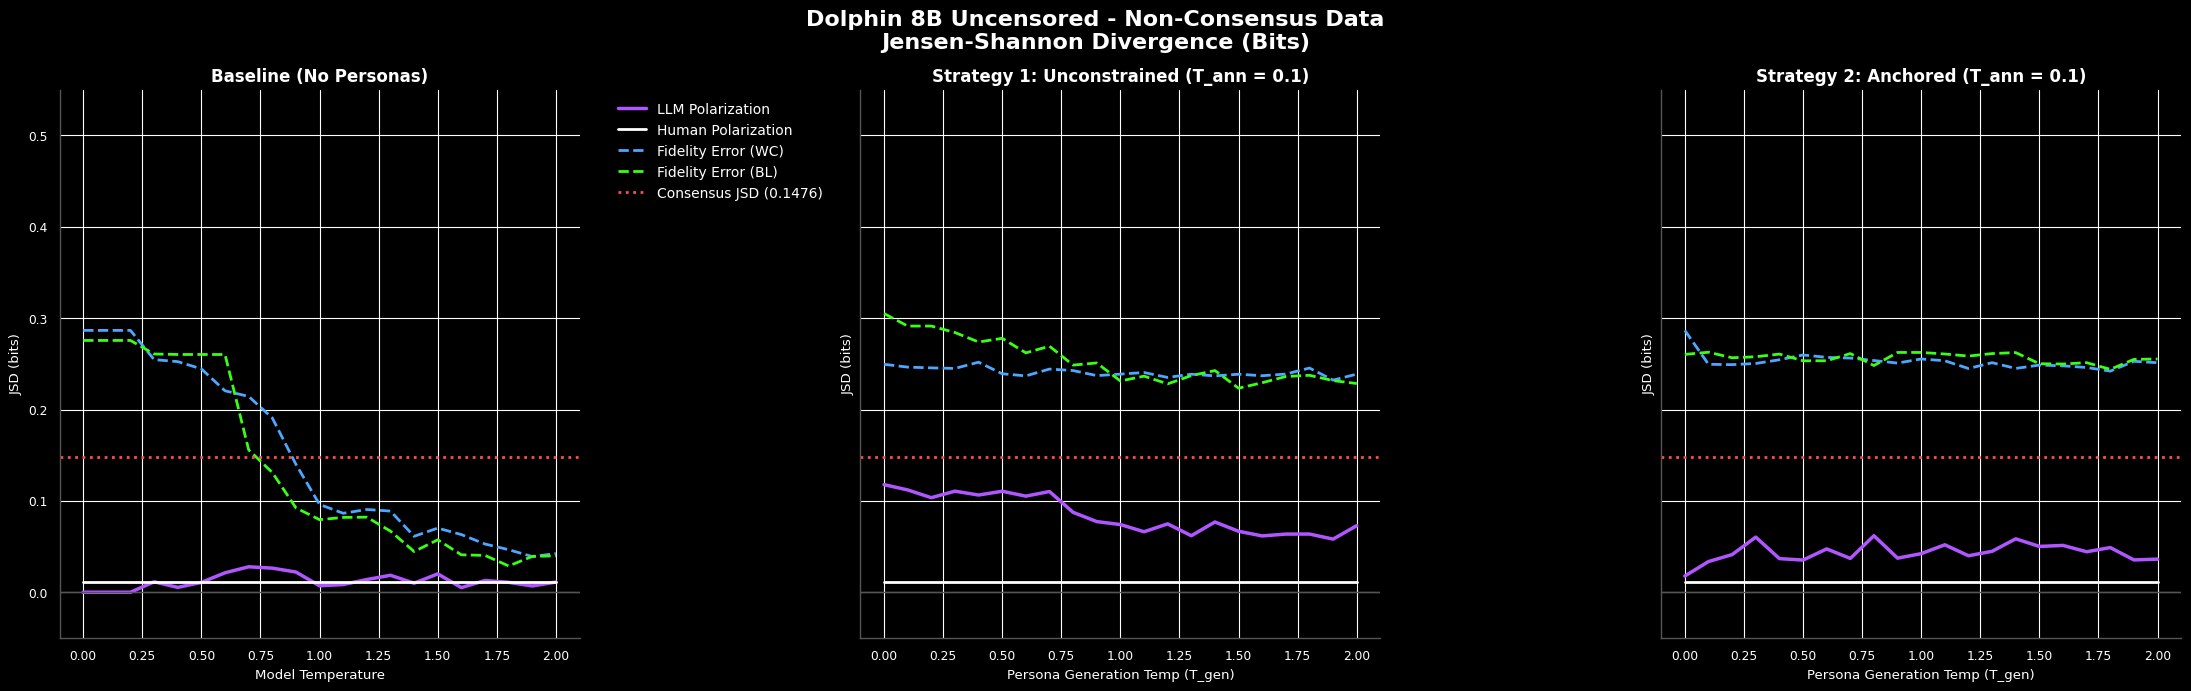

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Set dark background for inline notebook plots
#plt.style.use('dark_background')

def process_dolphin_folder(folder_path, prefix, is_consensus=False):
    """Generic extractor for Dolphin file naming conventions."""
    data = {'baseline': [], 'strat1': [], 'strat2': []}
    temps = [round(x * 0.1, 1) for x in range(21)]
    
    print(f"Processing {folder_path}...")
    for t in temps:
        # Baseline
        base_file = f"{folder_path}/{prefix}_baseline_T{t}_N50.csv"
        if os.path.exists(base_file):
            res = analyze_binary_dataset(pd.read_csv(base_file), white_cons_df, black_libs_df)
            if res: data['baseline'].append({'temp': t, **res})
        
        # Strategy 1
        s1_file = f"{folder_path}/{prefix}_2stage_strat1_Tgen{t}_Tann0.1_N50.csv"
        if os.path.exists(s1_file):
            res = analyze_binary_dataset(pd.read_csv(s1_file), white_cons_df, black_libs_df)
            if res: data['strat1'].append({'temp': t, **res})
            
        # Strategy 2
        s2_file = f"{folder_path}/{prefix}_2stage_strat2_Tgen{t}_Tann0.1_N50.csv"
        if os.path.exists(s2_file):
            res = analyze_binary_dataset(pd.read_csv(s2_file), white_cons_df, black_libs_df)
            if res: data['strat2'].append({'temp': t, **res})
            
    return data

def plot_3x1_panels(data_dict, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharex=True, sharey=True)
    fig.suptitle(f"{title_prefix}\nJensen-Shannon Divergence (Bits)", fontsize=16, weight='bold', y=0.98)
    
    configs = [
        ('baseline', 'Baseline (No Personas)', 'Model Temperature'),
        ('strat1', 'Strategy 1: Unconstrained (T_ann = 0.1)', 'Persona Generation Temp (T_gen)'),
        ('strat2', 'Strategy 2: Anchored (T_ann = 0.1)', 'Persona Generation Temp (T_gen)')
    ]
    
    for ax, (key, title, xlabel) in zip(axes, configs):
        df_plot = pd.DataFrame(data_dict[key])
        
        # FIX: Check if empty OR if 'pol_llm' is missing before doing anything
        if df_plot.empty or 'pol_llm' not in df_plot.columns:
            ax.set_title(f"{title} [NO DATA]", color='#ff4d4d')
            # Clean spines even if empty so it matches visually
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_color('#555555')
            ax.spines['bottom'].set_color('#555555')
            continue
            
        df_plot = df_plot.dropna(subset=['pol_llm'])
        
        ax.plot(df_plot['temp'], df_plot['pol_llm'], color='#b056ff', linewidth=2.5, label='LLM Polarization')
        ax.plot(df_plot['temp'], df_plot['pol_hum'], color='white', linewidth=2, label='Human Polarization')
        ax.plot(df_plot['temp'], df_plot['fid_wc'], color='#4da6ff', linestyle='--', linewidth=2, label='Fidelity Error (WC)')
        ax.plot(df_plot['temp'], df_plot['fid_bl'], color='#39ff14', linestyle='--', linewidth=2, label='Fidelity Error (BL)')
        
        ax.set_title(title, fontsize=12, weight='bold')
        ax.set_xlabel(xlabel)
        ax.set_ylabel("JSD (bits)")
        ax.set_ylim(-0.05, 0.55)
        
        # Clean spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#555555')
        ax.spines['bottom'].set_color('#555555')
        ax.axhline(0, color='#555555', linewidth=1)
        
        # Add consensus JSD reference line
        ax.axhline(0.1476, color='#ff4d4d', linestyle=':', linewidth=2, label='Consensus JSD (0.1476)')

    # Add legend only to the top plot to save space
    axes[0].legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=10, frameon=False, labelcolor='white')
    plt.tight_layout()
    plt.show()

# --- RUN DOLPHIN 8B (BINARY) ---
data_8b_bin = process_dolphin_folder("./data_dolphin_binary", "dolphin8b_binary")
plot_3x1_panels(data_8b_bin, "Dolphin 8B Uncensored - Non-Consensus Data")

Processing ./data_dolphin_binary70...


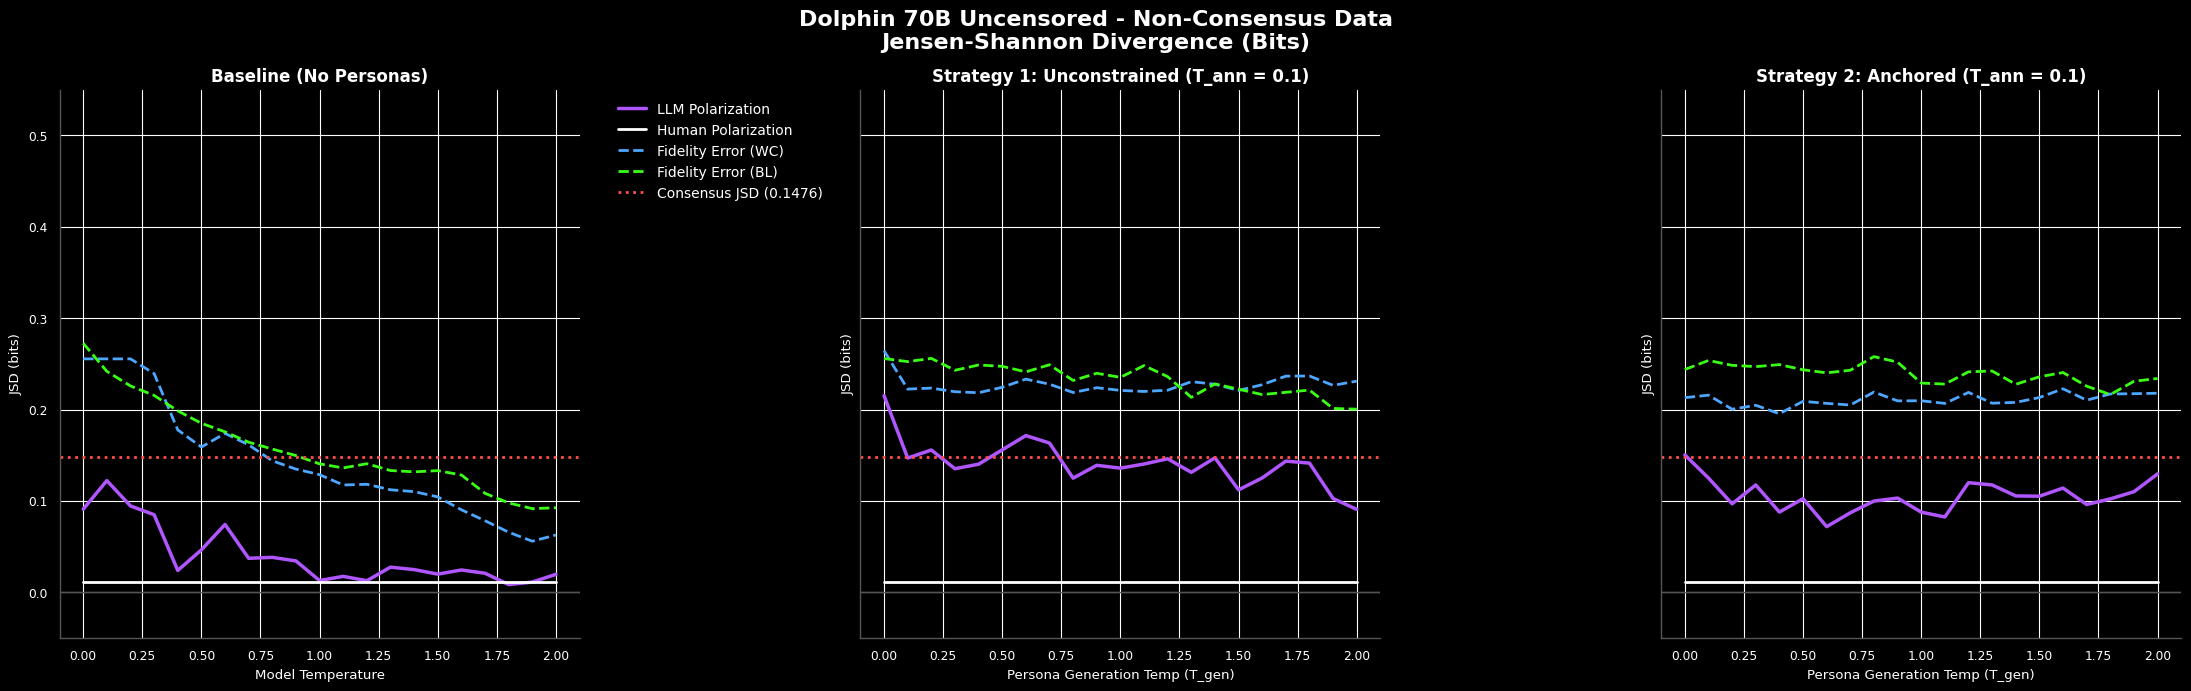

In [38]:
# --- RUN DOLPHIN 70B (BINARY) ---
data_70b_bin = process_dolphin_folder("./data_dolphin_binary70", "dolphin70b_binary")
plot_3x1_panels(data_70b_bin, "Dolphin 70B Uncensored - Non-Consensus Data")

Processing ./data_dolphin_consensus...


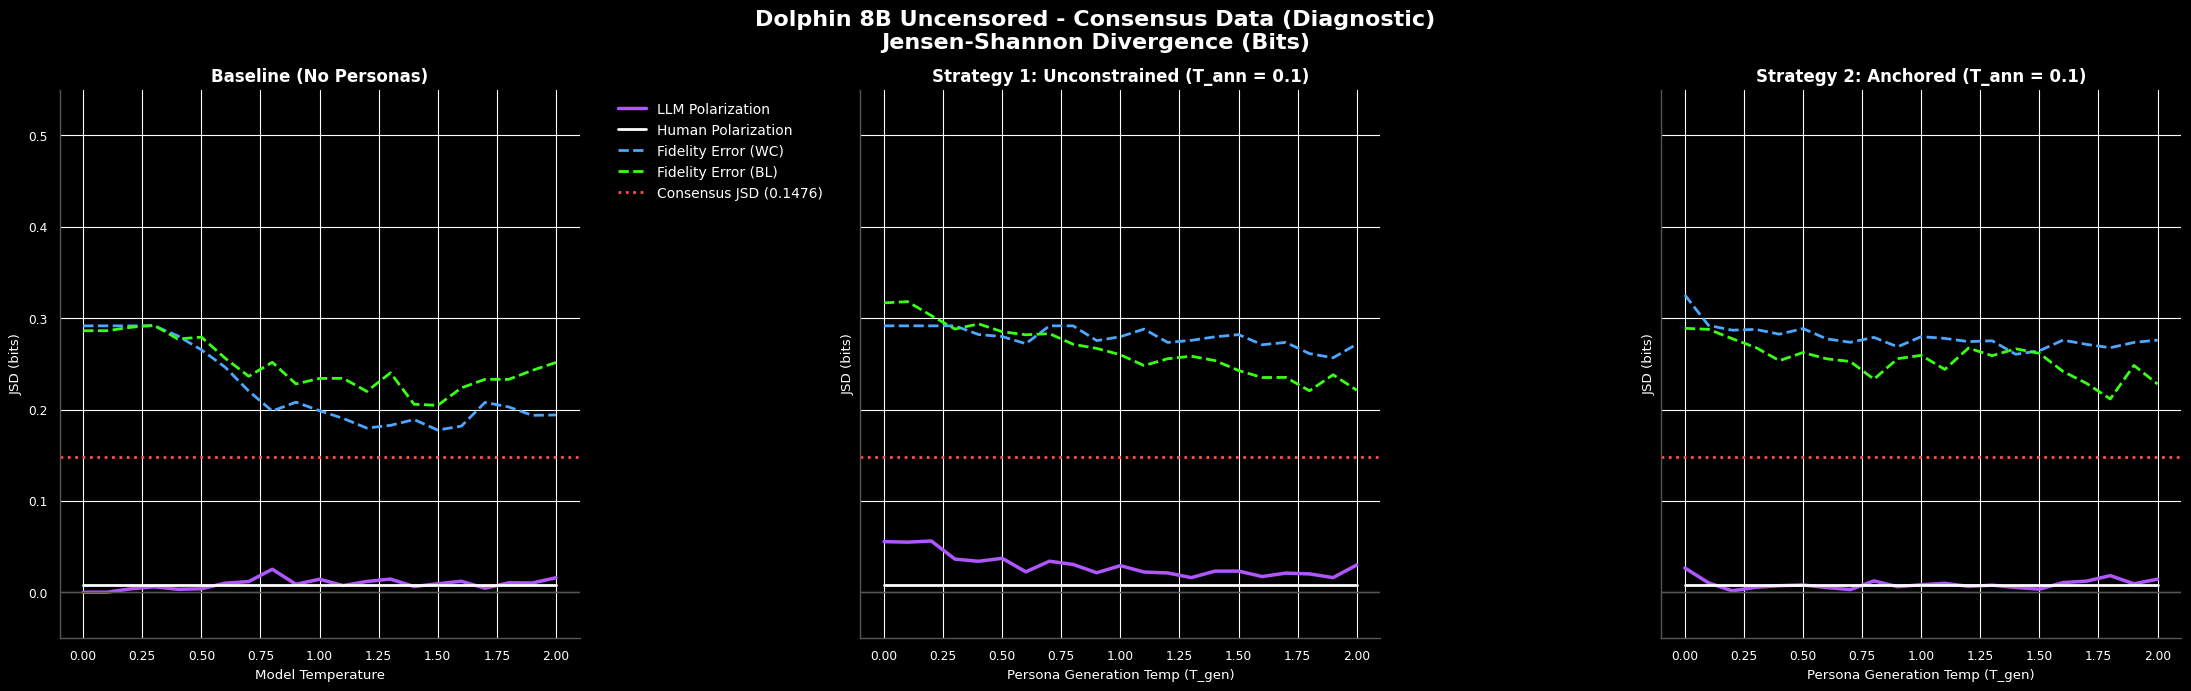

In [39]:
# --- RUN DOLPHIN 8B (CONSENSUS) ---
data_8b_cons = process_dolphin_folder("./data_dolphin_consensus", "dolphin8b_consensus")
plot_3x1_panels(data_8b_cons, "Dolphin 8B Uncensored - Consensus Data (Diagnostic)")

Processing ./data_dolphin_consensus70...


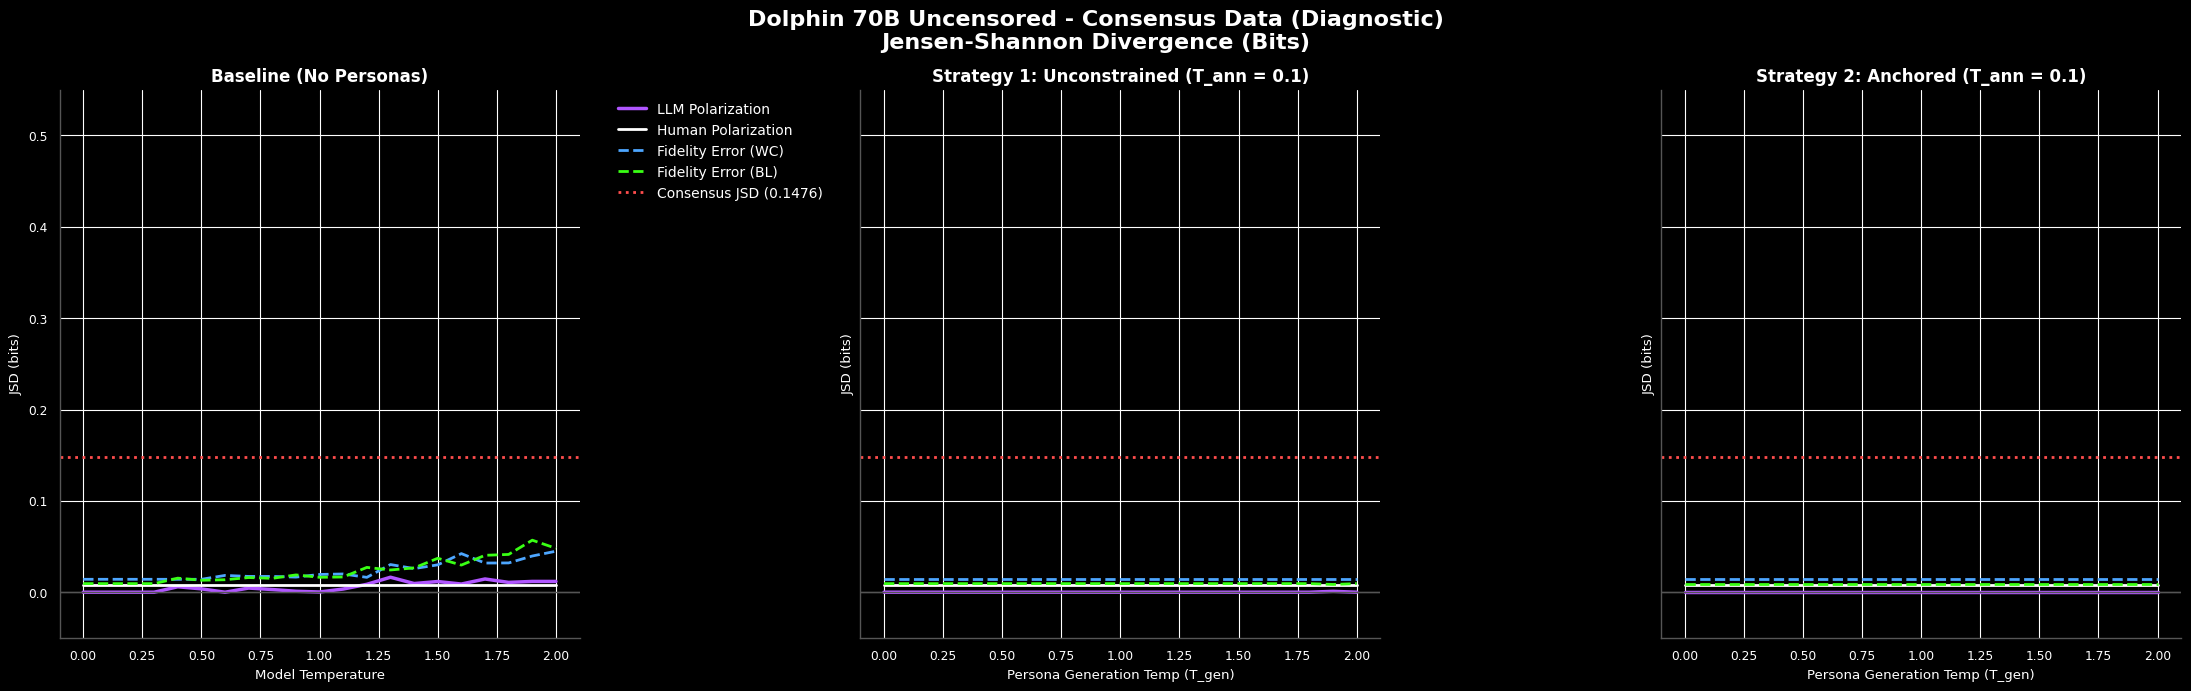

In [40]:
# --- RUN DOLPHIN 70B (CONSENSUS) ---
data_70b_cons = process_dolphin_folder("./data_dolphin_consensus70", "dolphin70b_consensus")
plot_3x1_panels(data_70b_cons, "Dolphin 70B Uncensored - Consensus Data (Diagnostic)")